# BÁO CÁO THỰC HÀNH LAB 2: ĐẶC TRƯNG TIẾNG NÓI VÀ NHẬN DẠNG BẰNG DTW
## HỌC PHẦN: CSE457 – XỬ LÝ ÂM THANH VÀ TIẾNG NÓI
### TRƯỜNG ĐẠI HỌC THỦY LỢI • KHOA CÔNG NGHỆ THÔNG TIN • BỘ MÔN TRÍ TUỆ NHÂN TẠO

---
* **Họ và tên sinh viên**: Hồ Đức Minh
* **Mã số sinh viên (MSSV)**: 2351260669
* **Lớp**: Kỹ thuật Phần mềm / Công nghệ Thông tin
* **Bài thực hành**: Lab 2 – Đặc trưng tiếng nói và nhận dạng bằng DTW (Dynamic Time Warping)
* **Dataset**: Bộ từ vựng tiếng Việt 5 từ tách rời: `khong`, `mot`, `hai`, `ba`, `bon` (5 lần lặp / người nói)
---

## TỔNG QUAN HỆ THỐNG NHẬN DẠNG TỪ ĐƠN (ISOLATED WORD RECOGNIZER)

Quy trình xử lý âm thanh khép kín từ tín hiệu thô đến quyết định nhận dạng:
$$\text{Tín hiệu WAV (16kHz)} \longrightarrow \text{Pre-emphasis} \longrightarrow \text{Framing \& Windowing} \longrightarrow \text{Energy/ZCR VAD} \longrightarrow \text{FFT Spectrum} \longrightarrow \text{Mel Filterbank} \longrightarrow \text{Log-Mel} \longrightarrow \text{DCT-II (MFCC)} \longrightarrow \text{CMN} \longrightarrow \text{DTW Dynamic Programming} \longrightarrow \text{Decision}$$

Trong notebook này, **từng bước xử lý đều được hiển thị trực quan bằng hình ảnh và đồ thị kỹ thuật**, đi kèm phân tích vật lý và toán học sâu sắc.


### 1. Khai báo Môi trường và Tải Module Xử lý

In [1]:
import os
from pathlib import Path
import numpy as np
import scipy.signal as signal
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import Image, display

# Cấu hình đồ họa hiển thị inline
%matplotlib inline
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 120

# Import các hàm lõi và hàm vẽ từ pipeline.py
import pipeline as pl

print(f"Hệ thống đã sẵn sàng:")
print(f" - Tần số lấy mẫu: Fs = {pl.FS} Hz")
print(f" - Độ dài khung: {pl.FRAME_MS} ms ({pl.WIN_LEN} mẫu)")
print(f" - Bước nhảy hop: {pl.HOP_MS} ms ({pl.HOP_LEN} mẫu)")
print(f" - Bộ lọc Mel: {pl.N_MELS} bộ lọc tam giác")
print(f" - Hệ số MFCC: {pl.N_MFCC} hệ số")
print(f" - Từ vựng: {list(pl.VN_NAMES.values())}")


Hệ thống đã sẵn sàng:
 - Tần số lấy mẫu: Fs = 16000 Hz
 - Độ dài khung: 25 ms (400 mẫu)
 - Bước nhảy hop: 10 ms (160 mẫu)
 - Bộ lọc Mel: 24 bộ lọc tam giác
 - Hệ số MFCC: 13 hệ số
 - Từ vựng: ['Không', 'Một', 'Hai', 'Ba', 'Bốn']


### Bước 1: Dạng sóng Thời gian Thô (Raw Waveforms)
* **Mục đích**: Kiểm tra biên độ, hình dạng phong bì sóng của 5 từ vựng tiếng Việt (`khong`, `mot`, `hai`, `ba`, `bon`).
* **Tại sao phải làm**: Đảm bảo tín hiệu không bị hiện tượng tràn biên độ (clipping), có khoảng lặng tự nhiên ở hai đầu ($0.25 - 0.45\text{ s}$) và biên độ đã được chuẩn hóa về $[-1.0, 1.0]$.



[BƯỚC 1] Vẽ waveform thô của cả 5 từ...


  ✔ Đã lưu  figures/step01_raw_waveforms.png


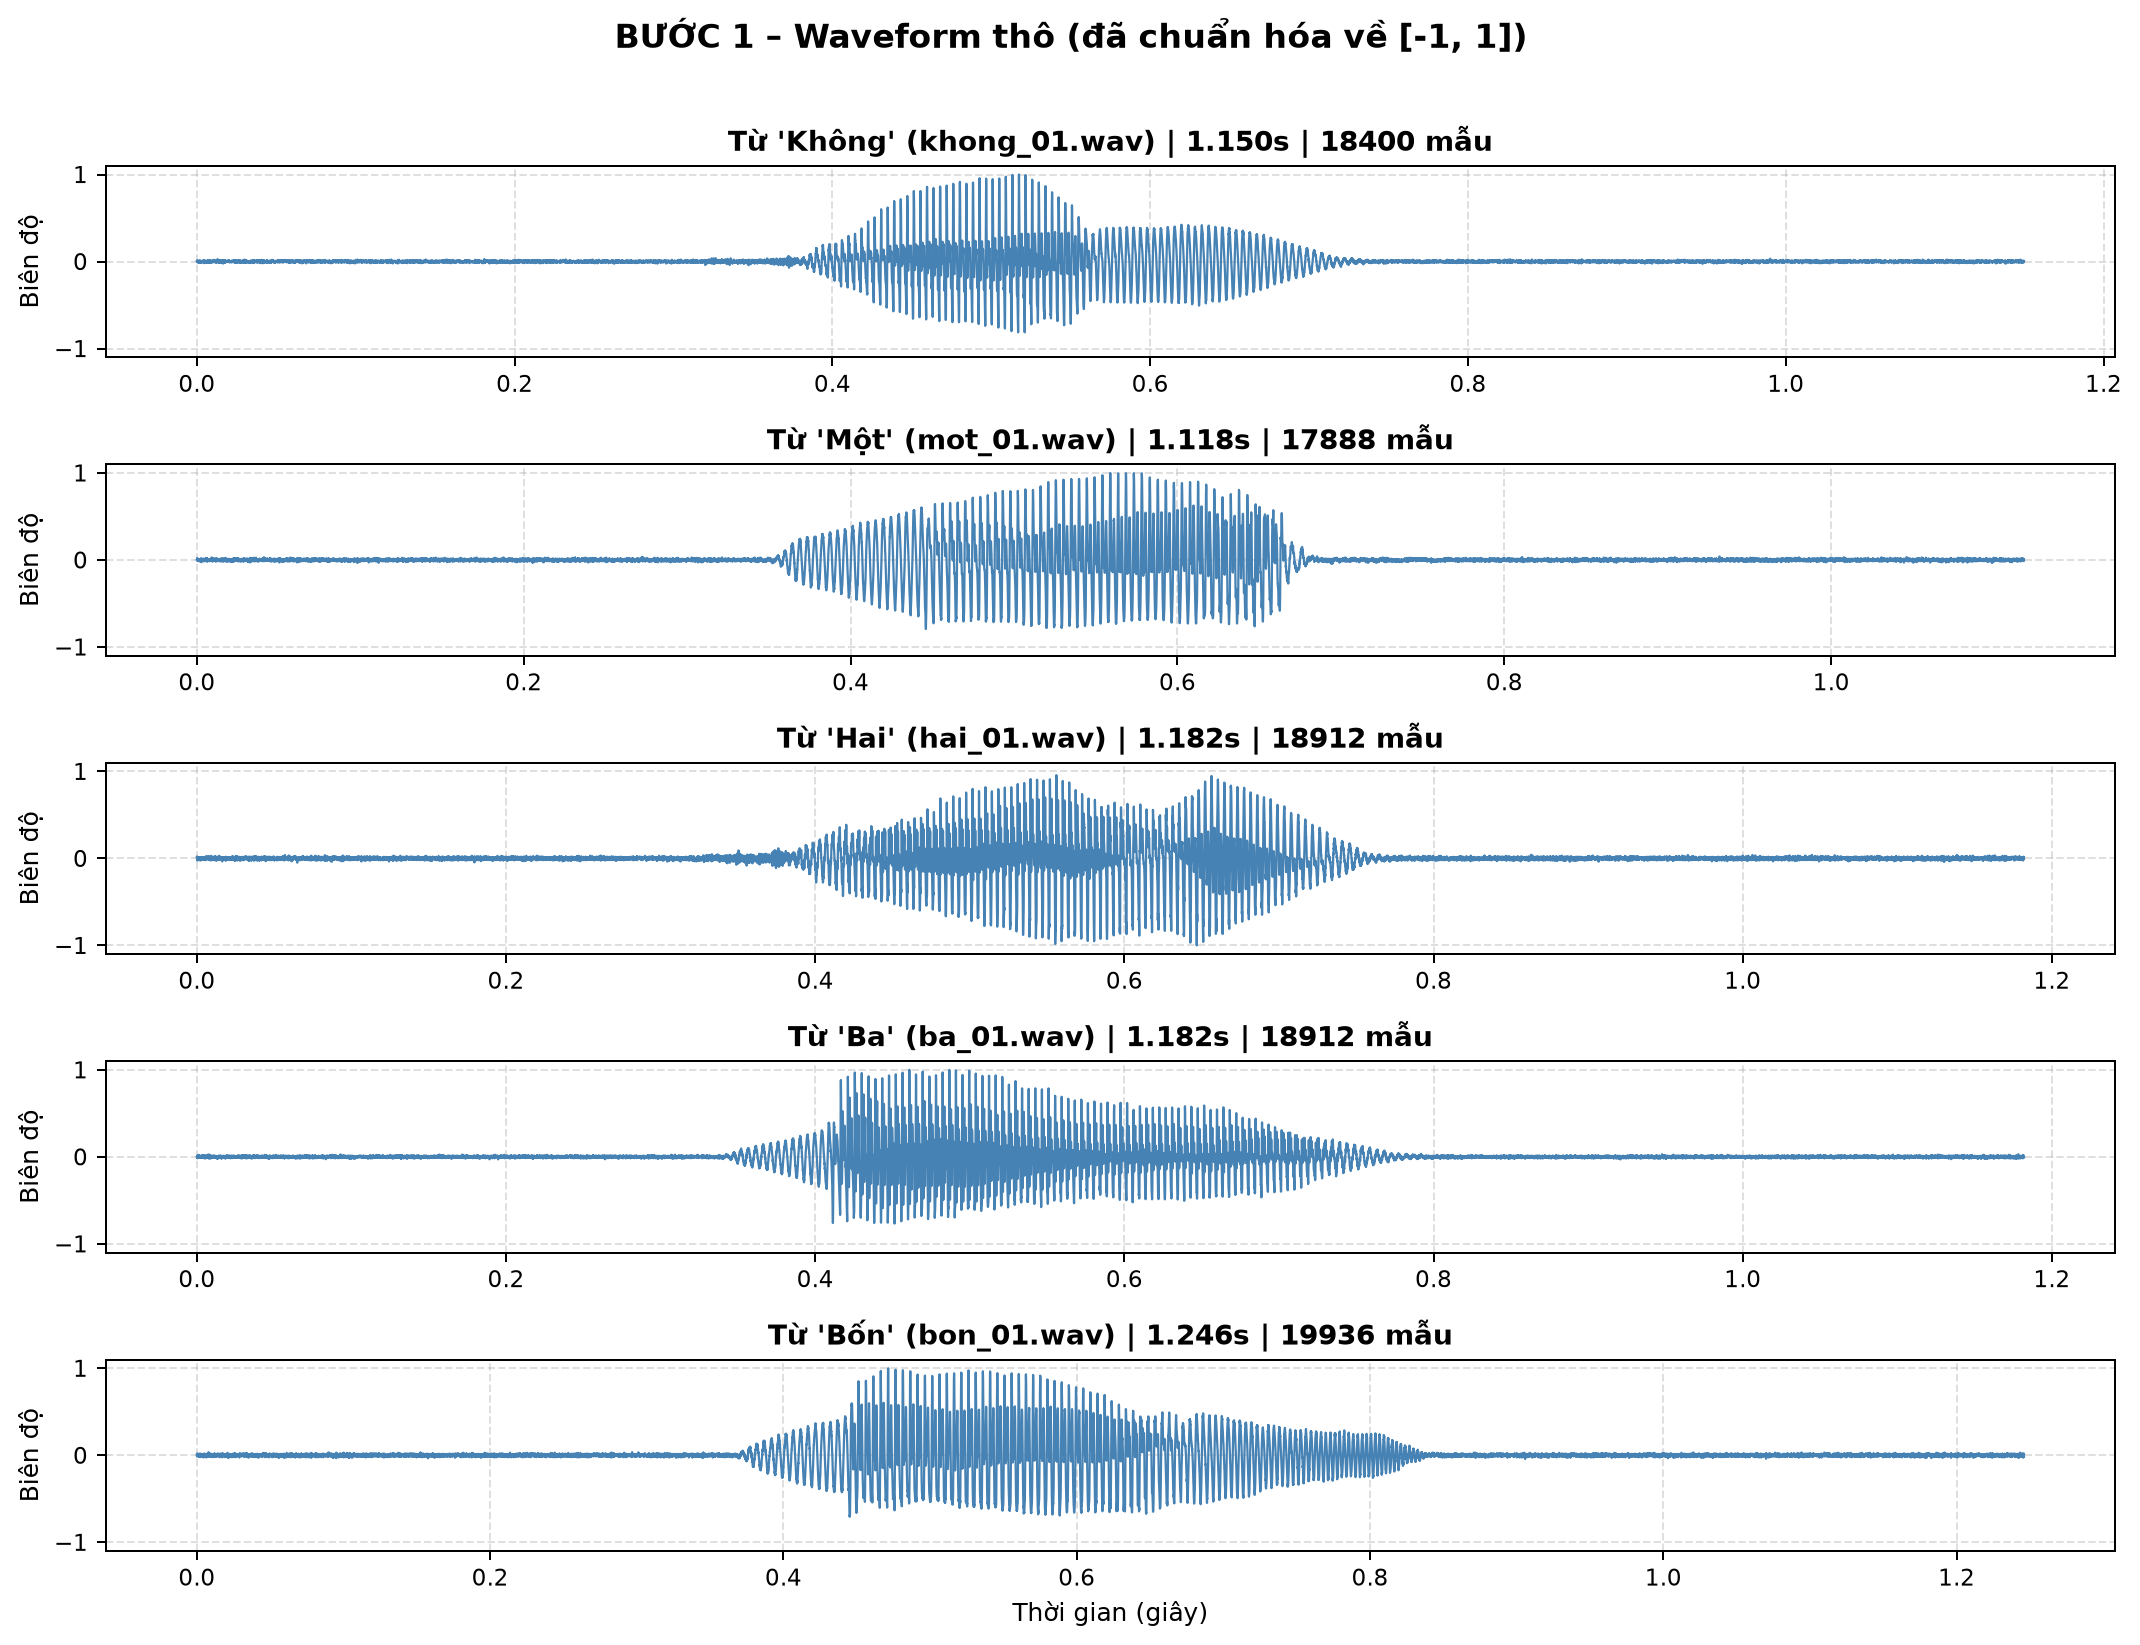

In [2]:
pl.plot_step01_raw_waveforms()
display(Image(filename="figures/step01_raw_waveforms.png"))


### Bước 2: Bộ lọc Tiền nhấn (Pre-emphasis Filter)
* **Công thức**: $y[n] = x[n] - \alpha x[n-1]$ với $\alpha = 0.97$.
* **Tại sao phải làm**: Bức xạ âm thanh tại môi trường tự do (Lip Radiation) làm suy hao tần số cao với tốc độ $-6\text{ dB/octave}$. Tiền nhấn đóng vai trò là bộ lọc thông cao bậc 1, giúp nâng dải tần số cao, làm phẳng phổ (spectral flattening) và cải thiện SNR của các formant bậc cao ($F_2, F_3$).


[BƯỚC 2] Vẽ tác dụng Pre-emphasis...


  ✔ Đã lưu  figures/step02_pre_emphasis.png


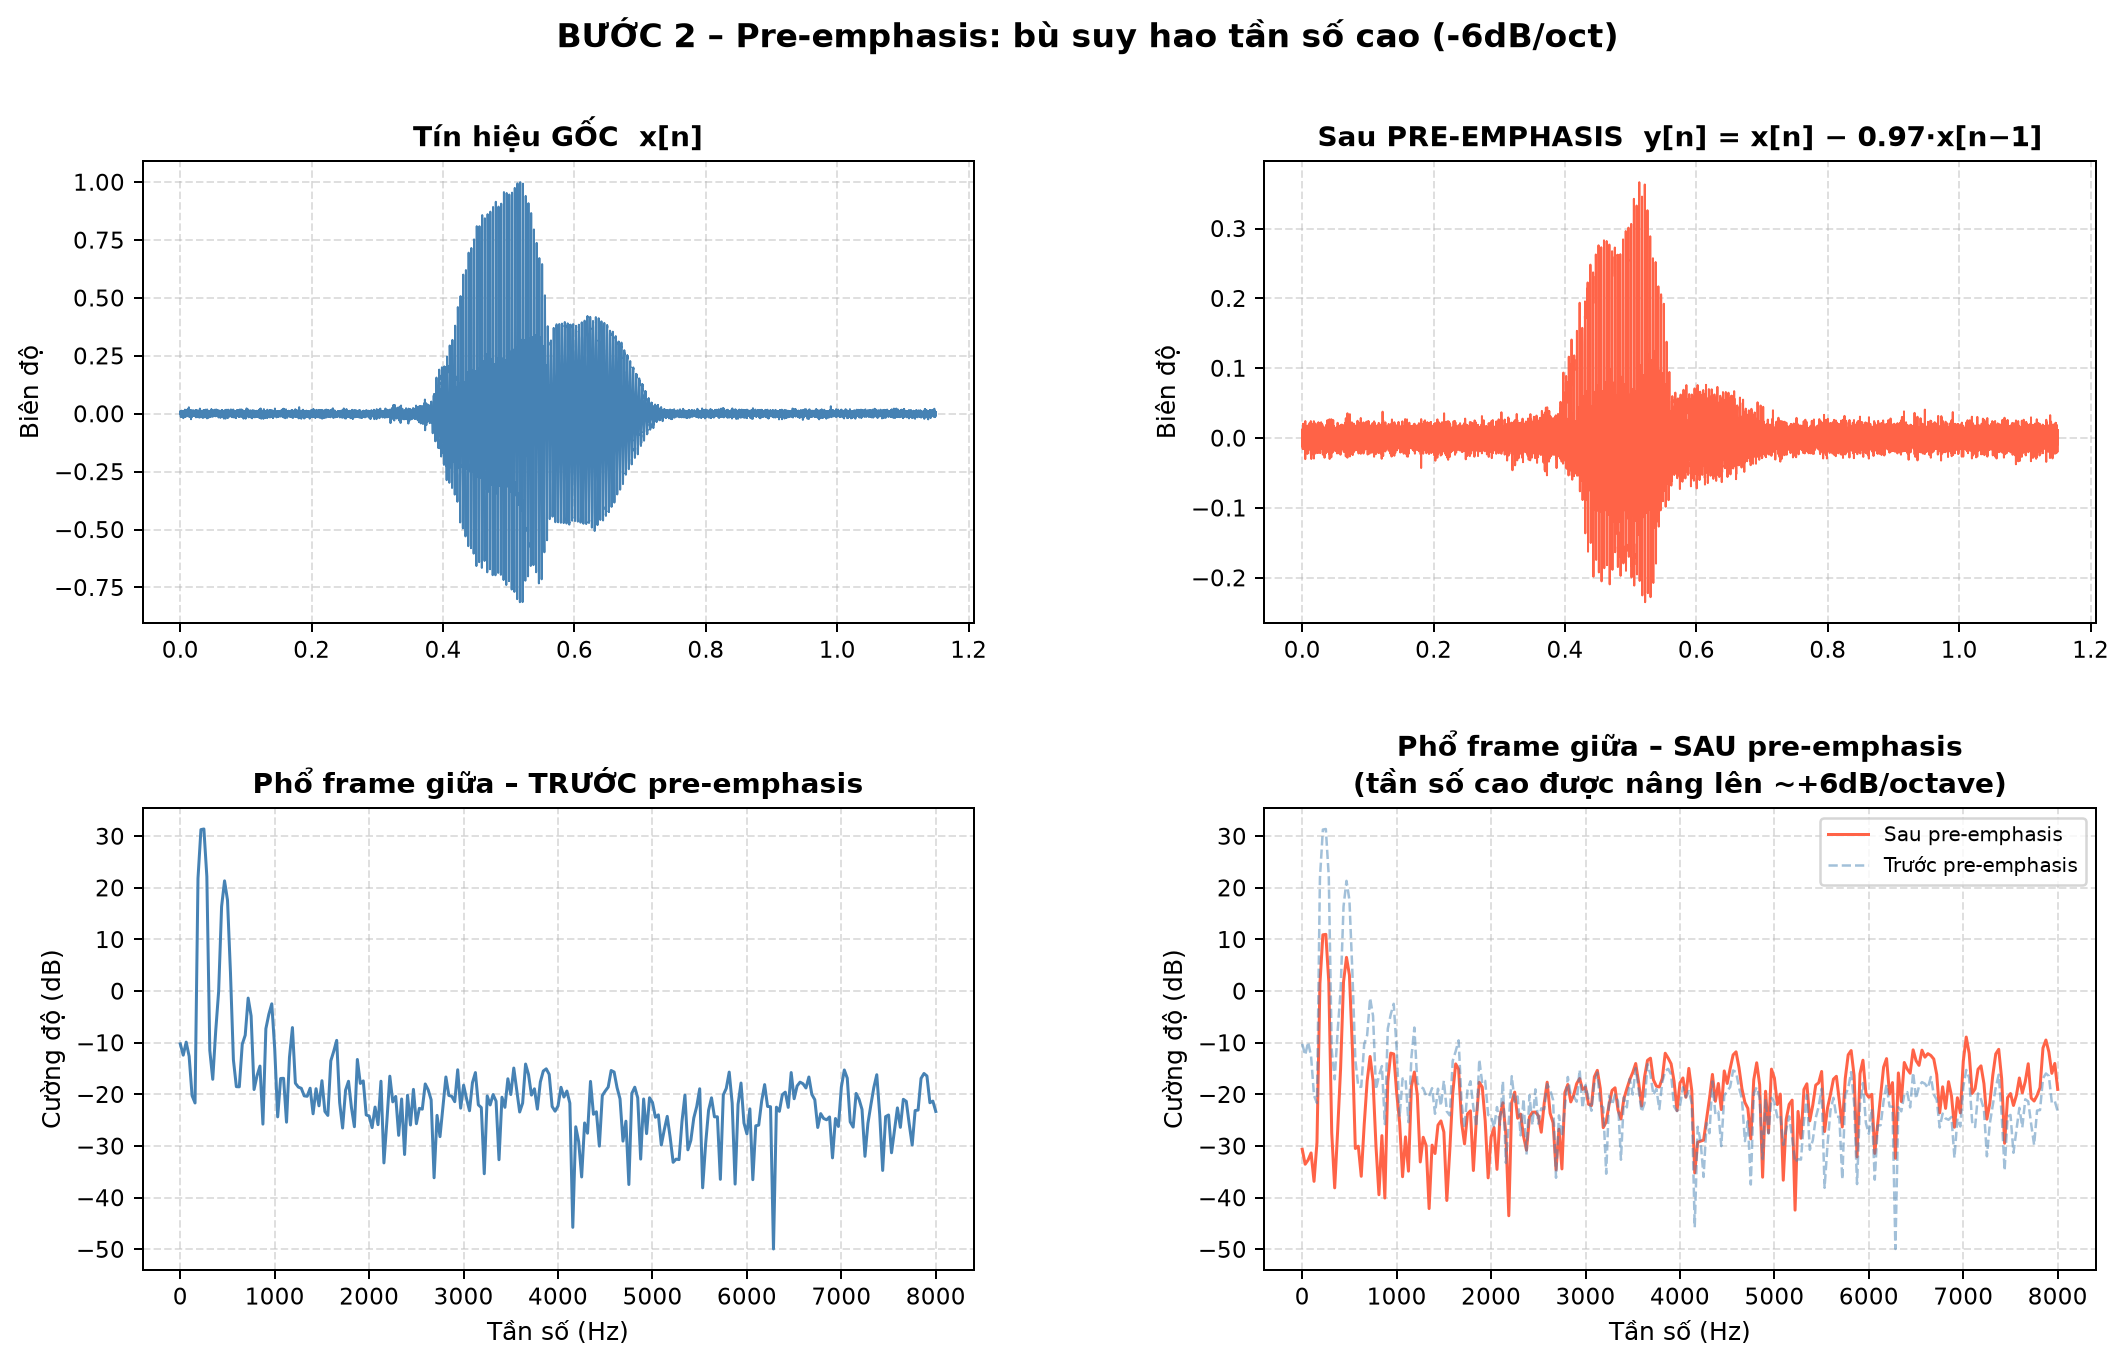

In [3]:
pl.plot_step02_pre_emphasis()
display(Image(filename="figures/step02_pre_emphasis.png"))


### Bước 3: Phân khung và Cửa sổ hóa (Framing & Windowing)
* **Tại sao phải làm**: Tiếng nói là tín hiệu biến đổi liên tục nhưng có tính chất **tựa dừng (quasi-stationary)** trong các đoạn ngắn $20 - 30\text{ ms}$. Chia khung $25\text{ ms}$ (400 mẫu) với bước dịch $10\text{ ms}$ (160 mẫu) cho phép phân tích Fourier cục bộ.
* **Cửa sổ Hamming**: $w[n] = 0.54 - 0.46 \cos\left(\frac{2\pi n}{L-1}\right)$. Làm thon biên độ về 0 ở hai đầu khung, triệt tiêu sự không liên tục giả tạo tại biên, giảm hiện tượng rò rỉ phổ (spectral leakage).


[BƯỚC 3] Vẽ Framing + Hamming window...


  ✔ Đã lưu  figures/step03_framing_windowing.png


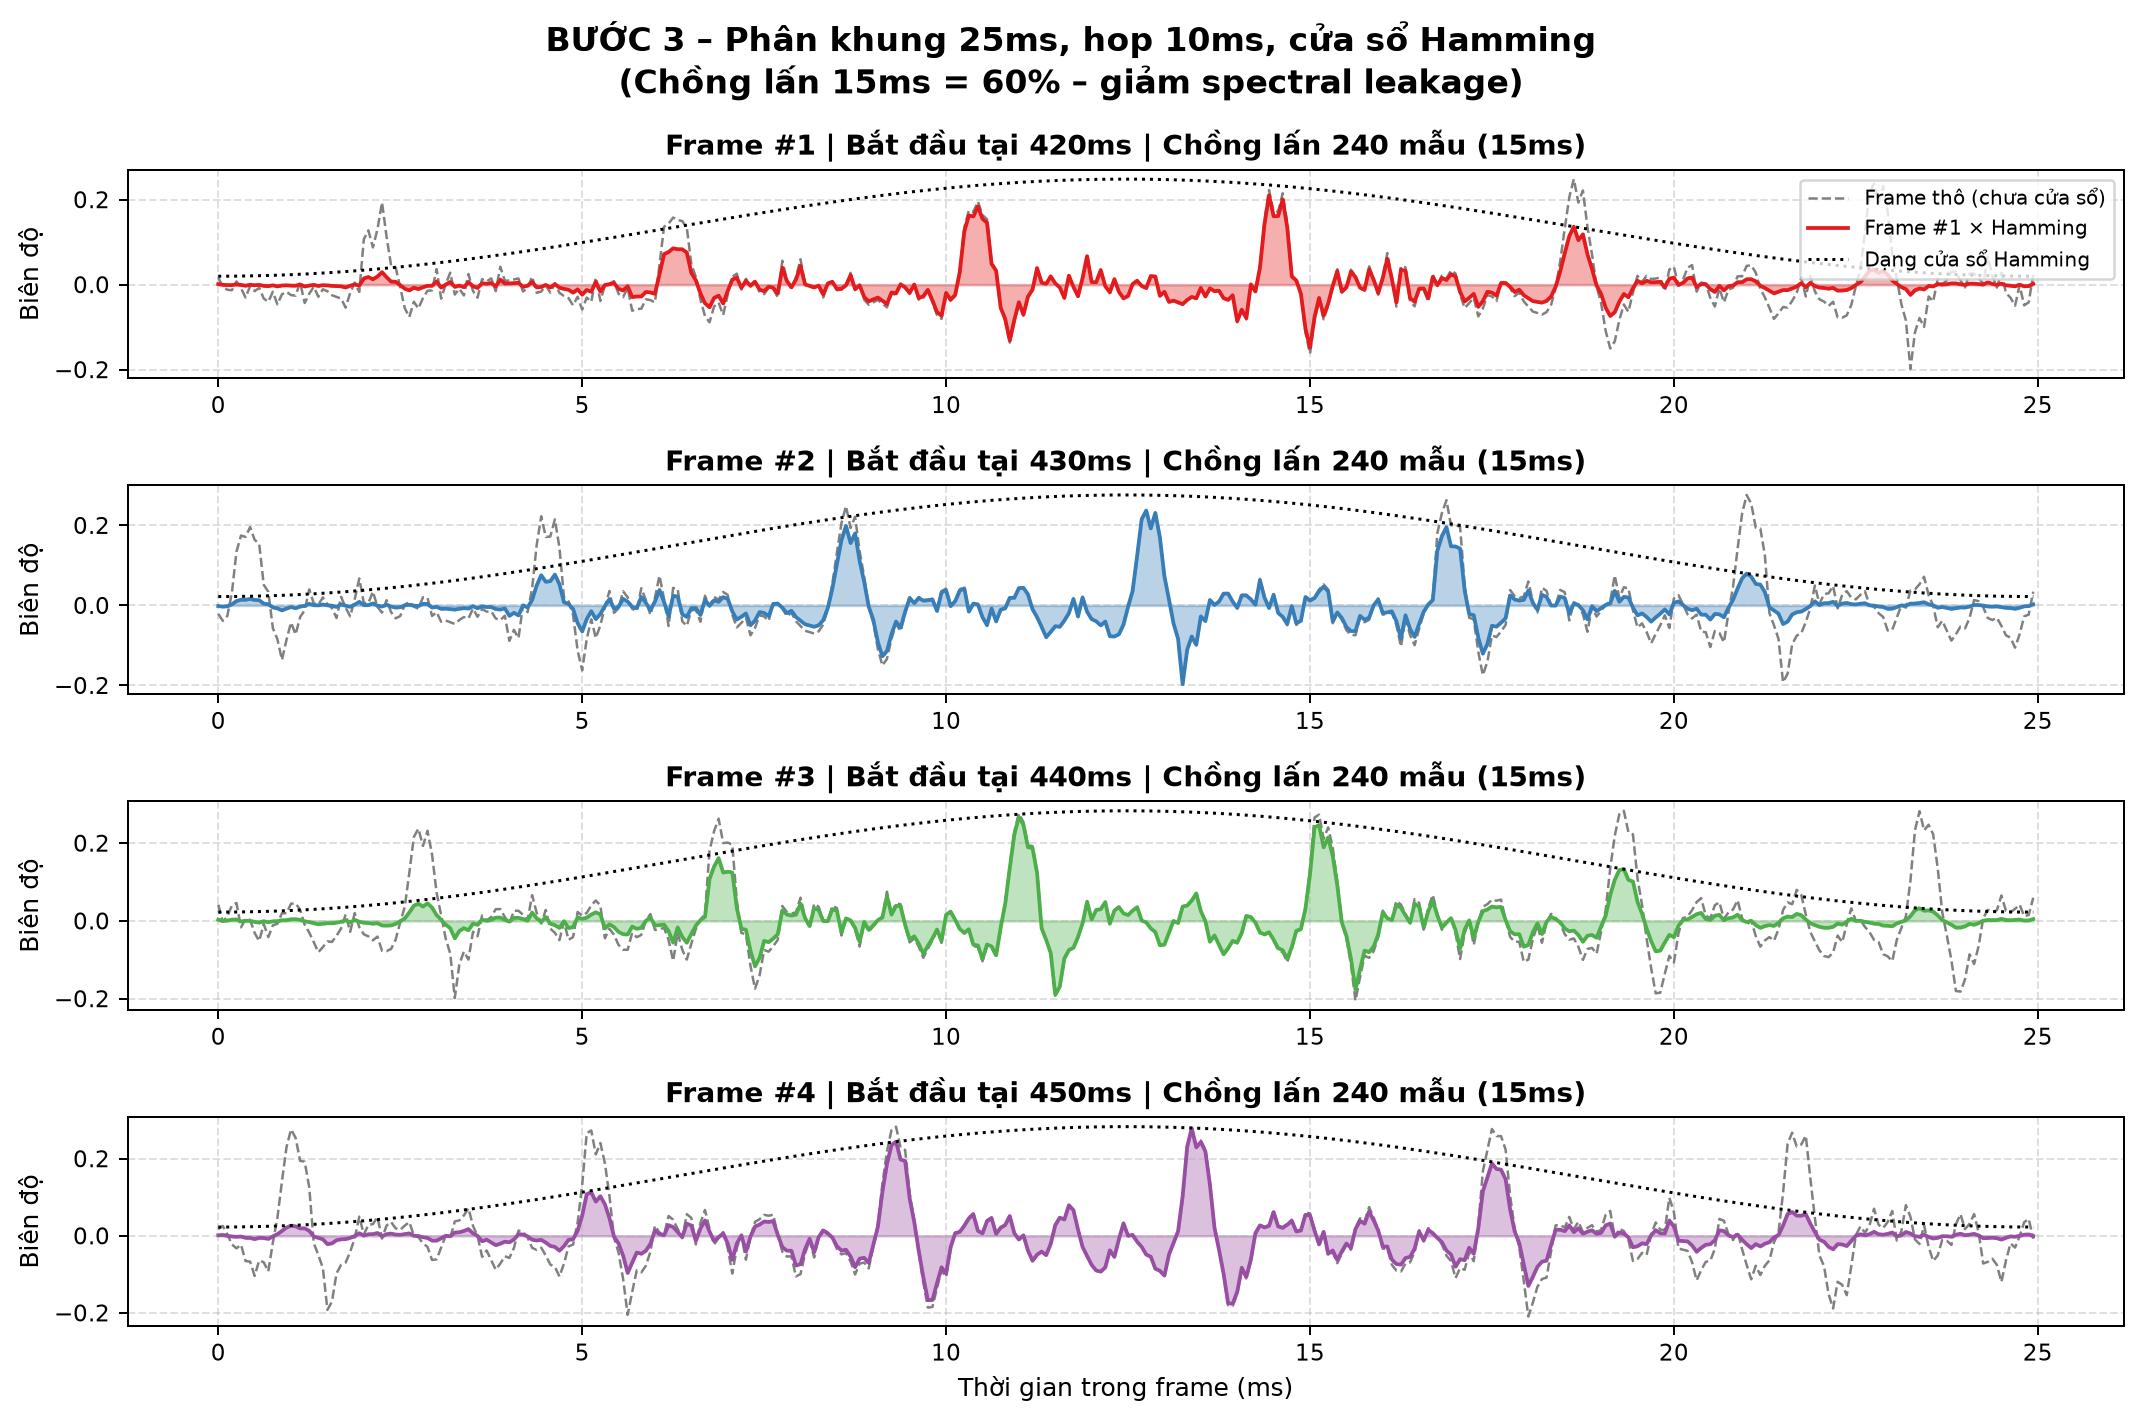

In [4]:
pl.plot_step03_framing_windowing()
display(Image(filename="figures/step03_framing_windowing.png"))


### Bước 4: Phổ Công suất FFT (FFT Power Spectrum)
* **Công thức**: $X_r[k] = \sum_{n=0}^{L-1} x_r[n] w[n] e^{-j 2\pi k n / N_{\text{fft}}}$, $P_r[k] = \frac{|X_r[k]|^2}{N_{\text{fft}}}$.
* **Tại sao phải làm**: Chuyển tín hiệu từ miền thời gian sang miền tần số để quan sát phân bố năng lượng theo tần số. Phổ công suất làm nổi bật các đỉnh cộng hưởng âm học (Formants $F_1, F_2, F_3$), mang thông tin cốt lõi để nhận diện nguyên âm.


[BƯỚC 4] Vẽ FFT Power Spectrum...


  ✔ Đã lưu  figures/step04_power_spectrum.png


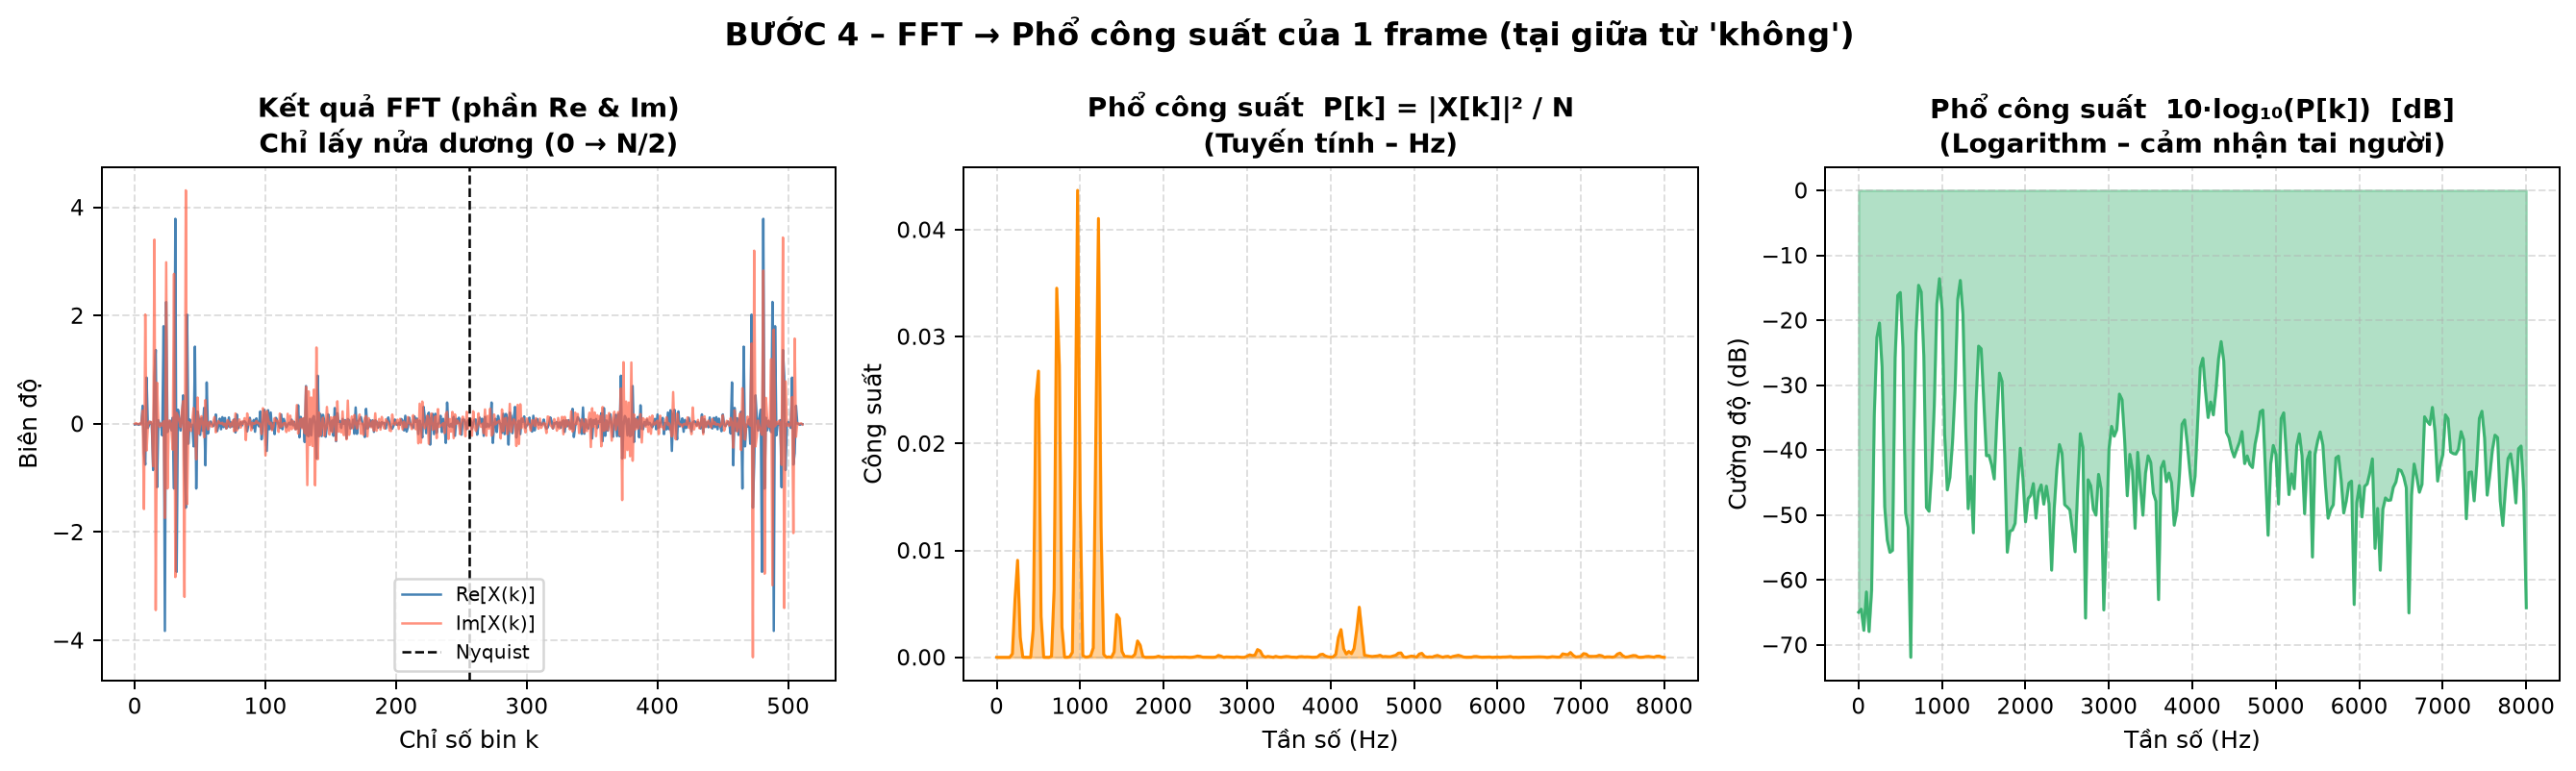

In [5]:
pl.plot_step04_power_spectrum()
display(Image(filename="figures/step04_power_spectrum.png"))


### Bước 5: Ngân hàng Bộ lọc Mel (Mel Filterbank)
* **Công thức**: $B(f) = 1125 \ln\left(1 + \frac{f}{700}\right)$.
* **Tại sao phải làm**: Thính giác con người cảm nhận tần số phi tuyến tính — cực kỳ nhạy bén ở tần số thấp ($< 1000\text{ Hz}$) nhưng giảm độ phân giải ở tần số cao. $M = 24$ bộ lọc tam giác Mel được phân bố cách đều trên thang Mel, khi ánh xạ về Hz sẽ dày ở tần số thấp và rộng dần ở tần số cao, mô phỏng cơ chế dải băng tới hạn (Critical Bands) của màng đáy ốc tai.


[BƯỚC 5] Vẽ Mel Filterbank...


  ✔ Đã lưu  figures/step05_mel_filterbank.png


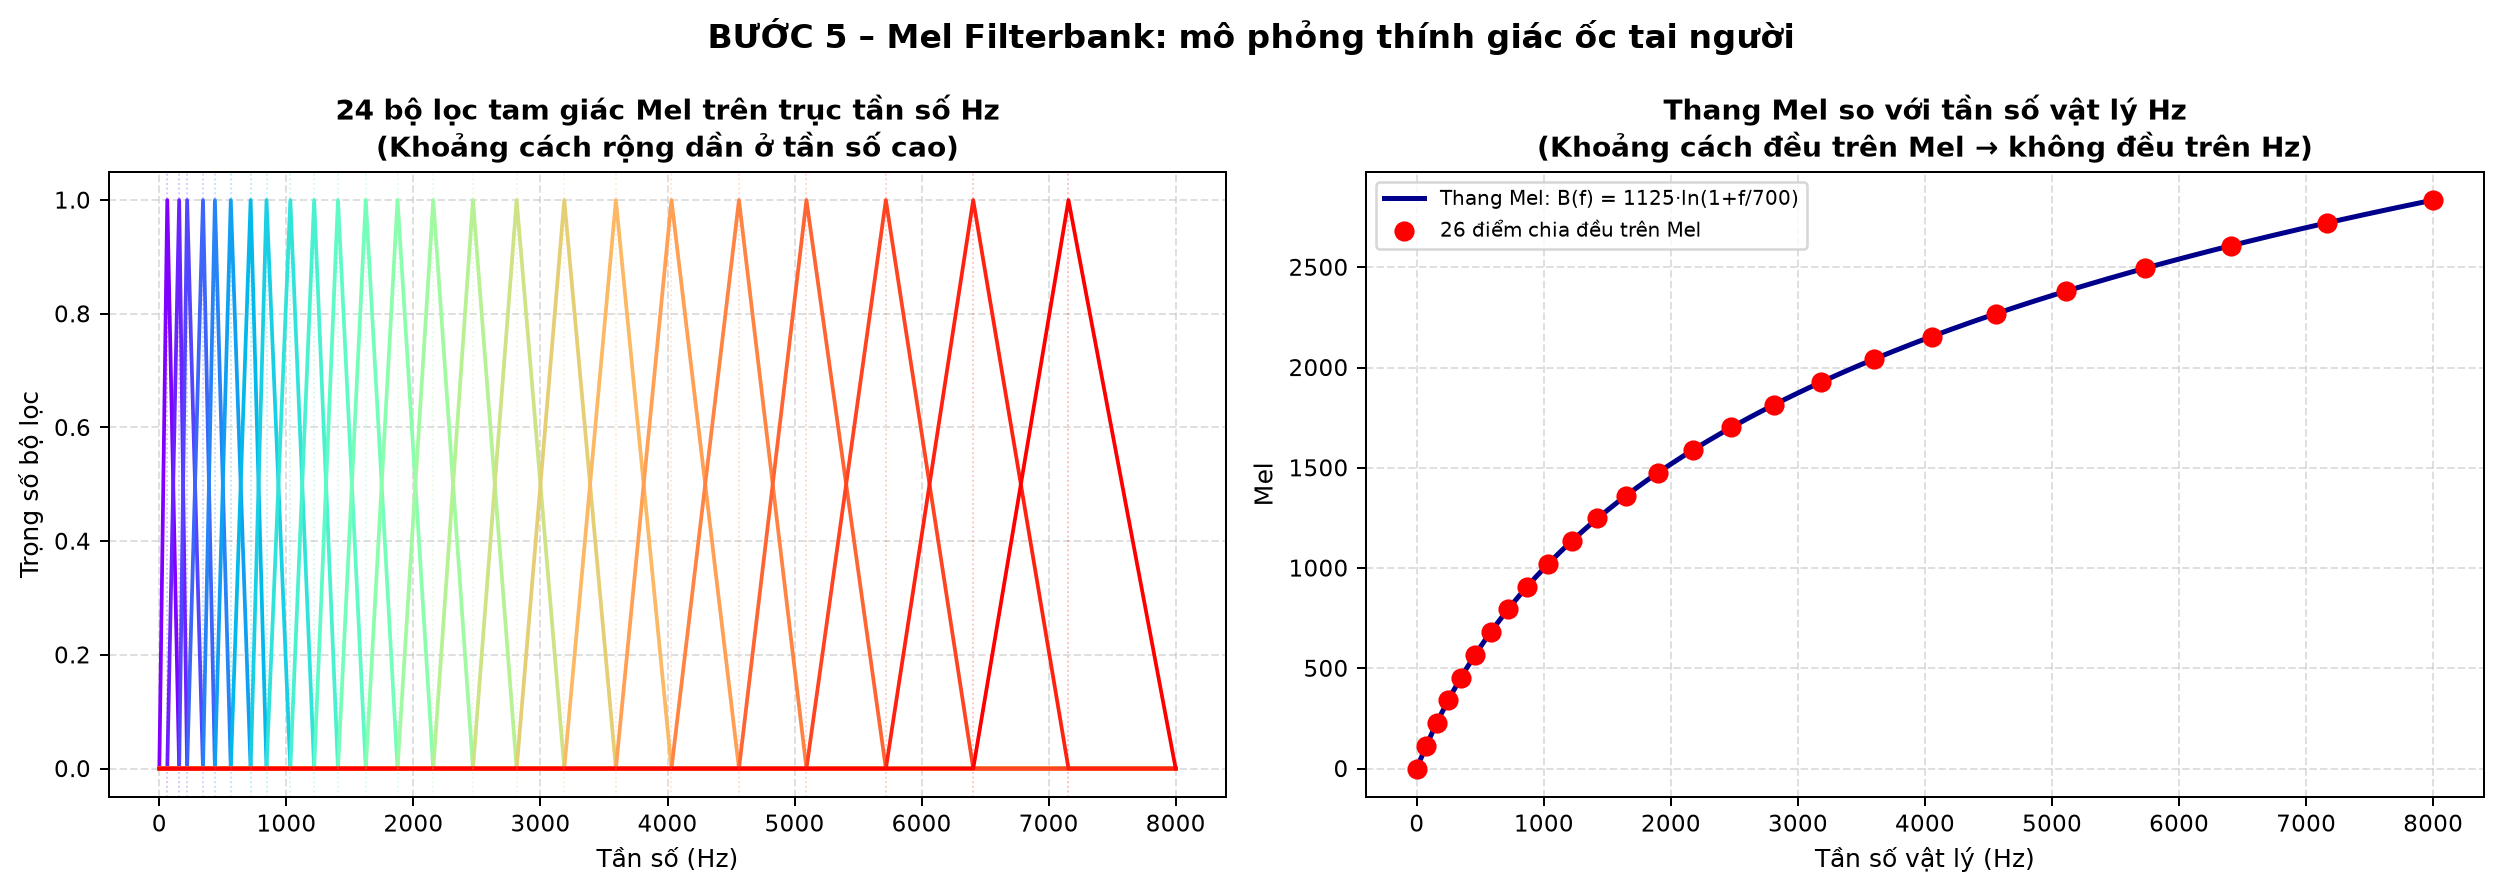

In [6]:
pl.plot_step05_mel_filterbank()
display(Image(filename="figures/step05_mel_filterbank.png"))


### Bước 6: Phổ Năng lượng Log-Mel (Log-Mel Spectrogram)
* **Công thức**: $S_r[m] = \ln\left( \sum_{k} P_r[k] H_m[k] + \varepsilon \right)$.
* **Tại sao phải làm**:
  1. **Nén dải động (Dynamic range compression)**: Thính giác người cảm nhận độ to theo quy luật logarit (thang dB / Weber-Fechner).
  2. **Giải chập đồng hình (Homomorphic deconvolution)**: Biến tích chập $S = E \cdot H$ (dây thanh âm $\times$ tuyến âm) thành phép cộng $\ln |S| = \ln |E| + \ln |H|$, mở đường cho việc tách đường bao phổ ở bước sau.


[BƯỚC 6] Vẽ Log-Mel Spectrogram...


  ✔ Đã lưu  figures/step06_log_mel_spectrogram.png


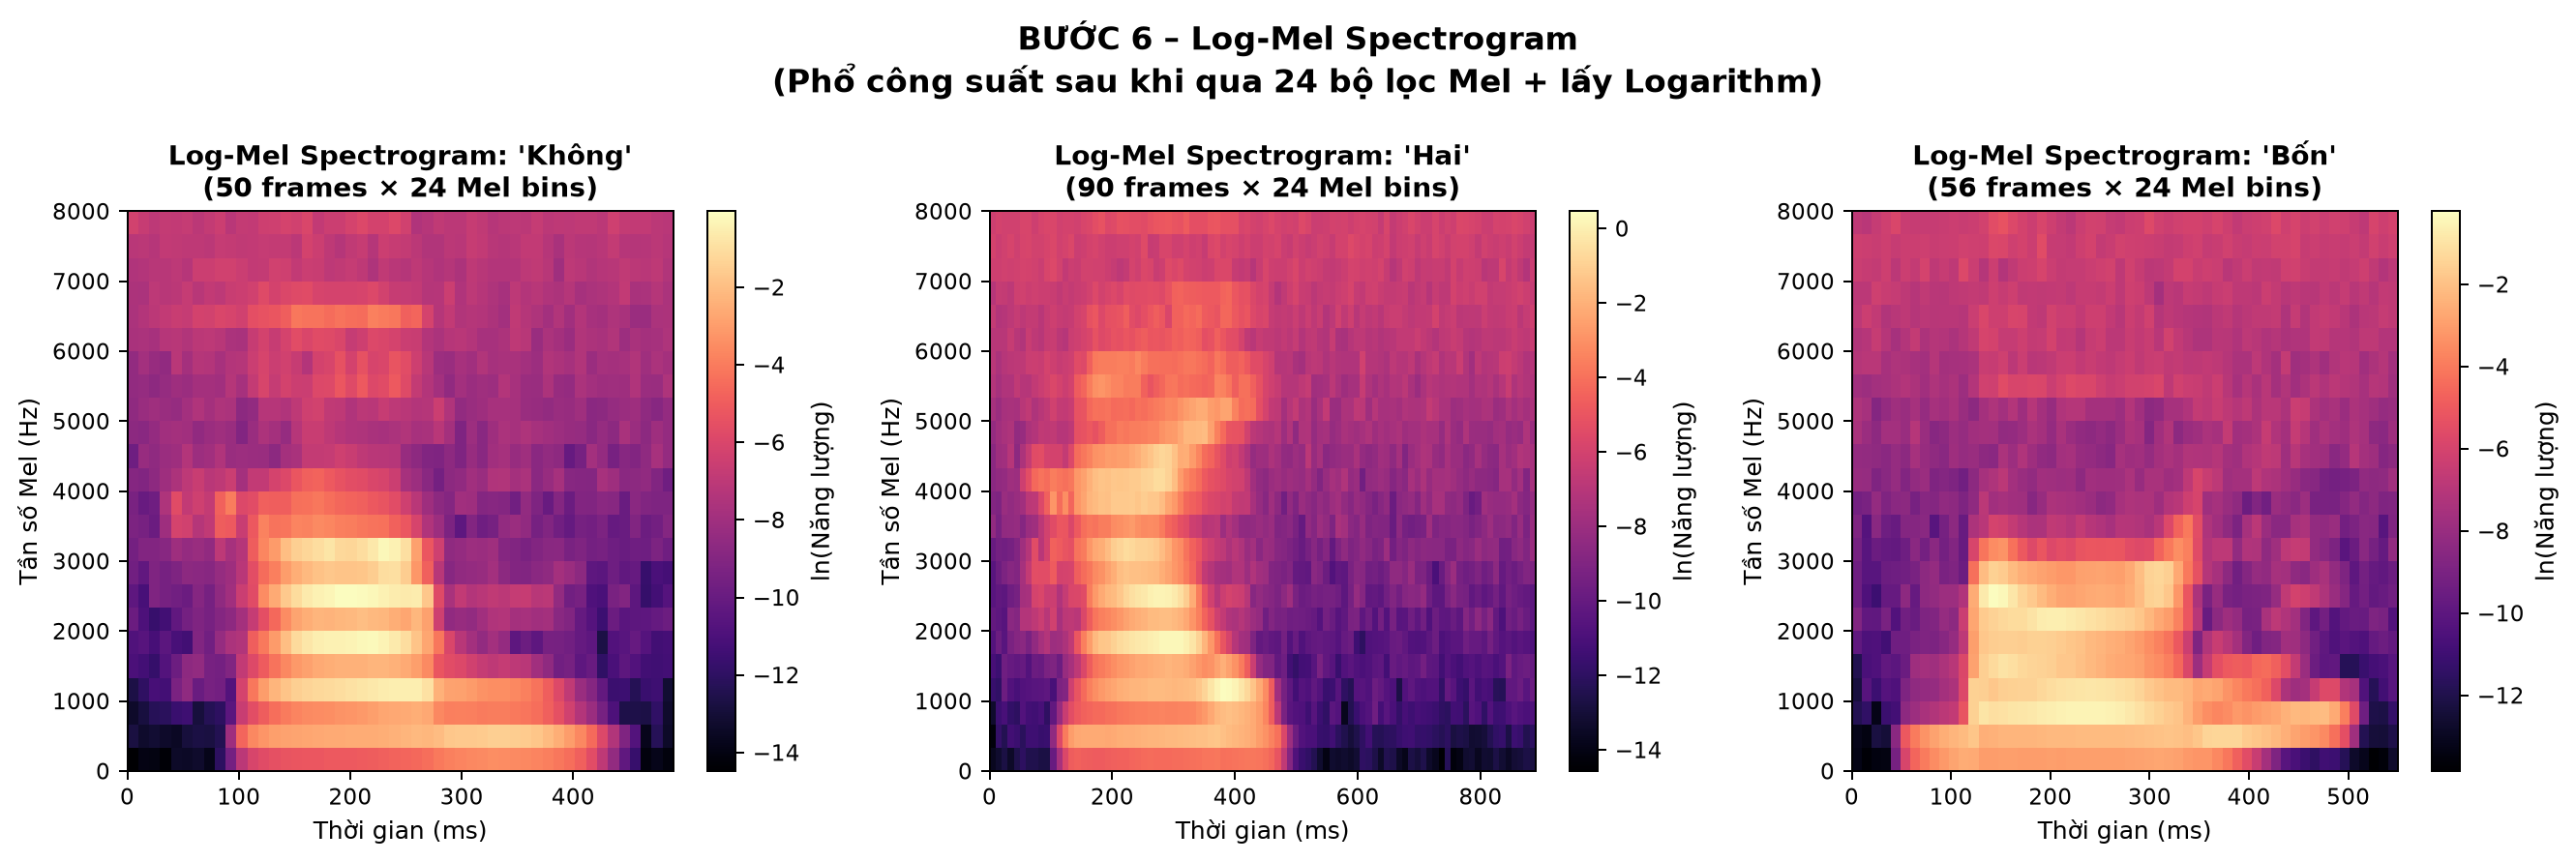

In [7]:
pl.plot_step06_log_mel_spectrogram()
display(Image(filename="figures/step06_log_mel_spectrogram.png"))


### Bước 7: Trích xuất MFCC Thô (Raw MFCC via DCT-II)
* **Công thức**: $c_r[n] = \sum_{m=0}^{M-1} S_r[m] \cos\left(\frac{\pi n (m + 0.5)}{M}\right), \quad n = 0, \dots, 12$.
* **Tại sao phải làm**: Biến đổi Cosine rời rạc (DCT) biến $M=24$ giá trị log-energy thành 13 hệ số Cepstral trực giao (khử tương quan giữa các kênh lọc). Các hệ số thấp ($c_1 - c_{12}$) biểu diễn biến thiên chậm theo tần số — chính là **đường bao tuyến âm (Spectral Envelope)**, loại bỏ thành phần biến thiên nhanh của tần số cơ bản $F_0$.


[BƯỚC 7] Vẽ MFCC thô (trước CMN)...


  ✔ Đã lưu  figures/step07_mfcc_raw.png


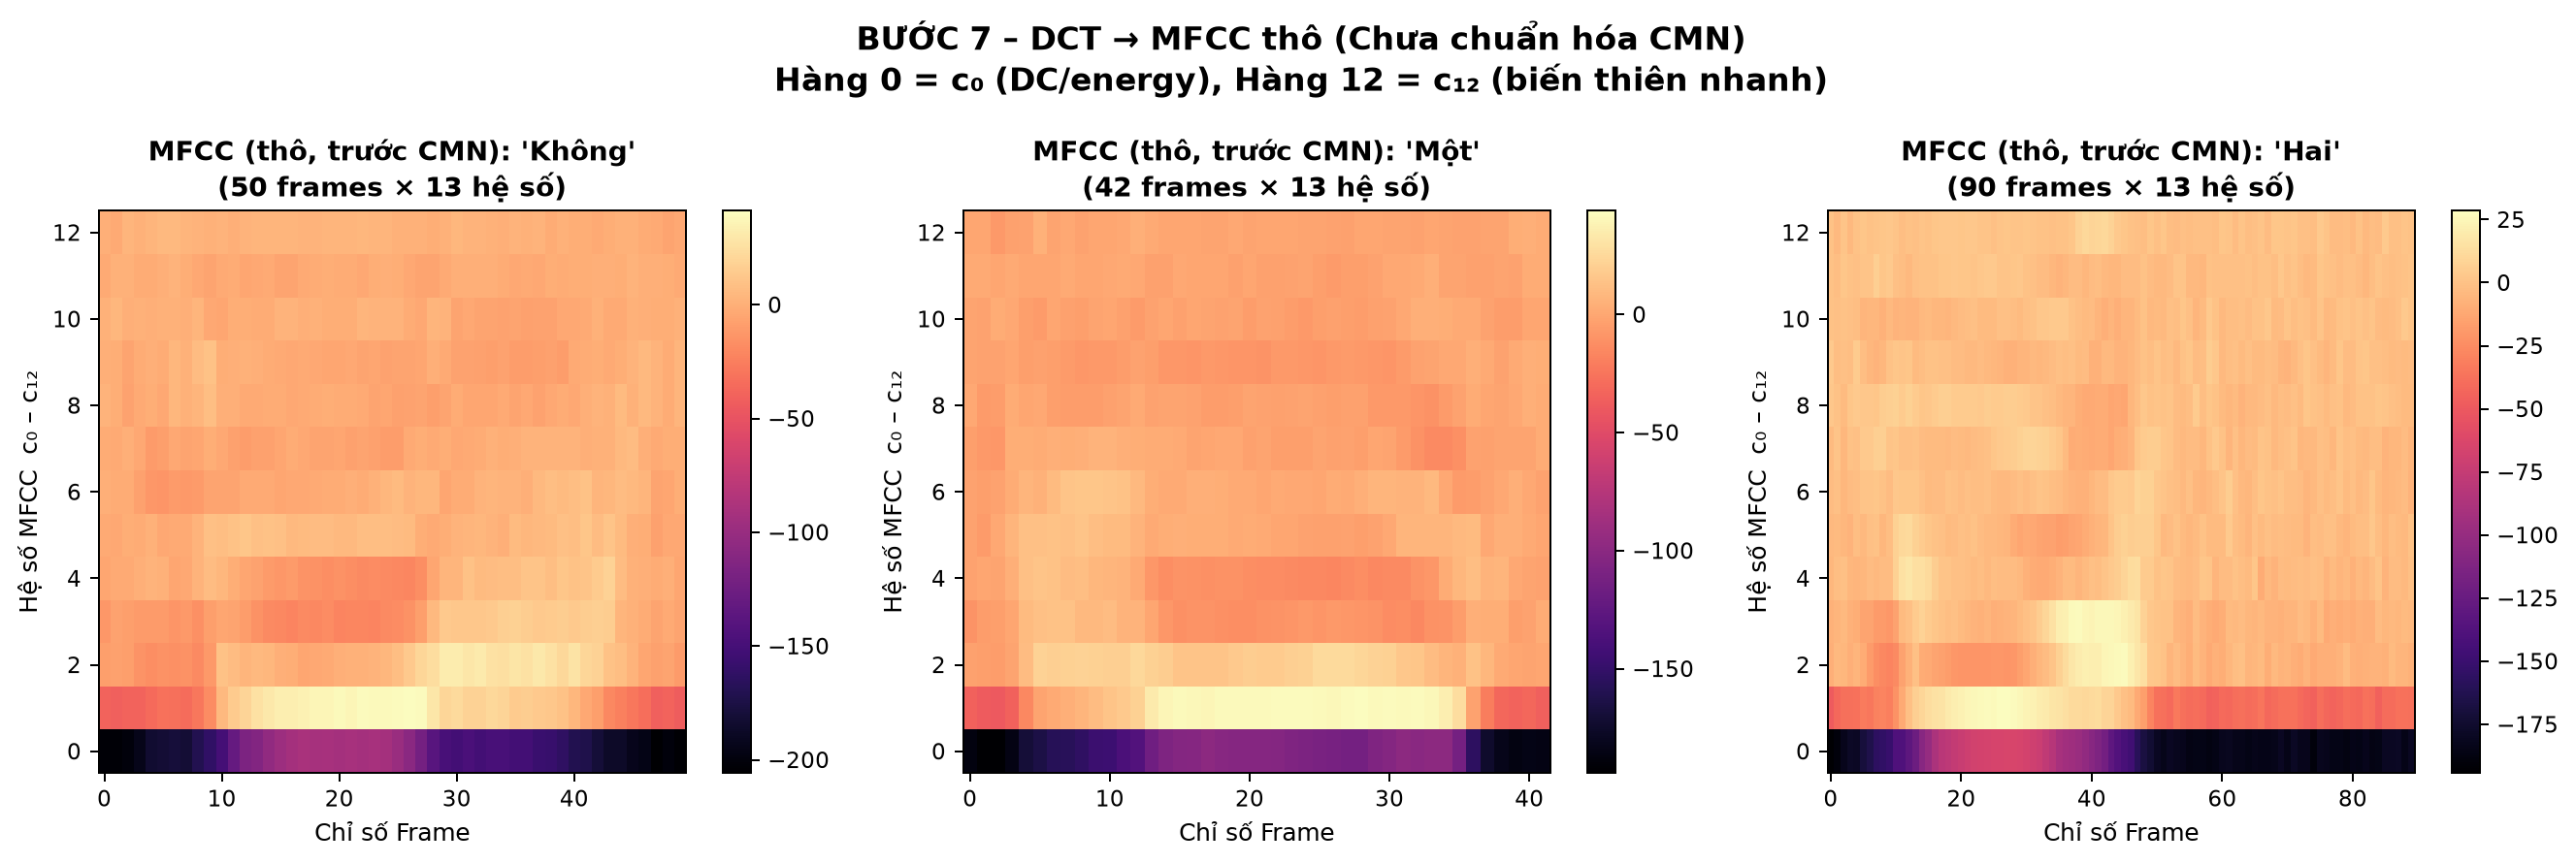

In [8]:
pl.plot_step07_mfcc_raw()
display(Image(filename="figures/step07_mfcc_raw.png"))


### Bước 8: Chuẩn hóa Trung bình Phổ (Cepstral Mean Normalization - CMN)
* **Công thức**: $\tilde{c}_t[n] = c_t[n] - \frac{1}{T} \sum_{t'=1}^T c_{t'}[n]$.
* **Tại sao phải làm**: Mỗi micro hoặc phòng thu có một hàm truyền tĩnh (channel transfer function) nhân vào tín hiệu $\rightarrow$ cộng vào miền Cepstrum. CMN trừ đi giá trị trung bình qua toàn bộ câu nói, triệt tiêu ảnh hưởng của micro và môi trường truyền, giúp đặc trưng ổn định hơn.


[BƯỚC 8] Vẽ tác dụng CMN...


  ✔ Đã lưu  figures/step08_cmn.png


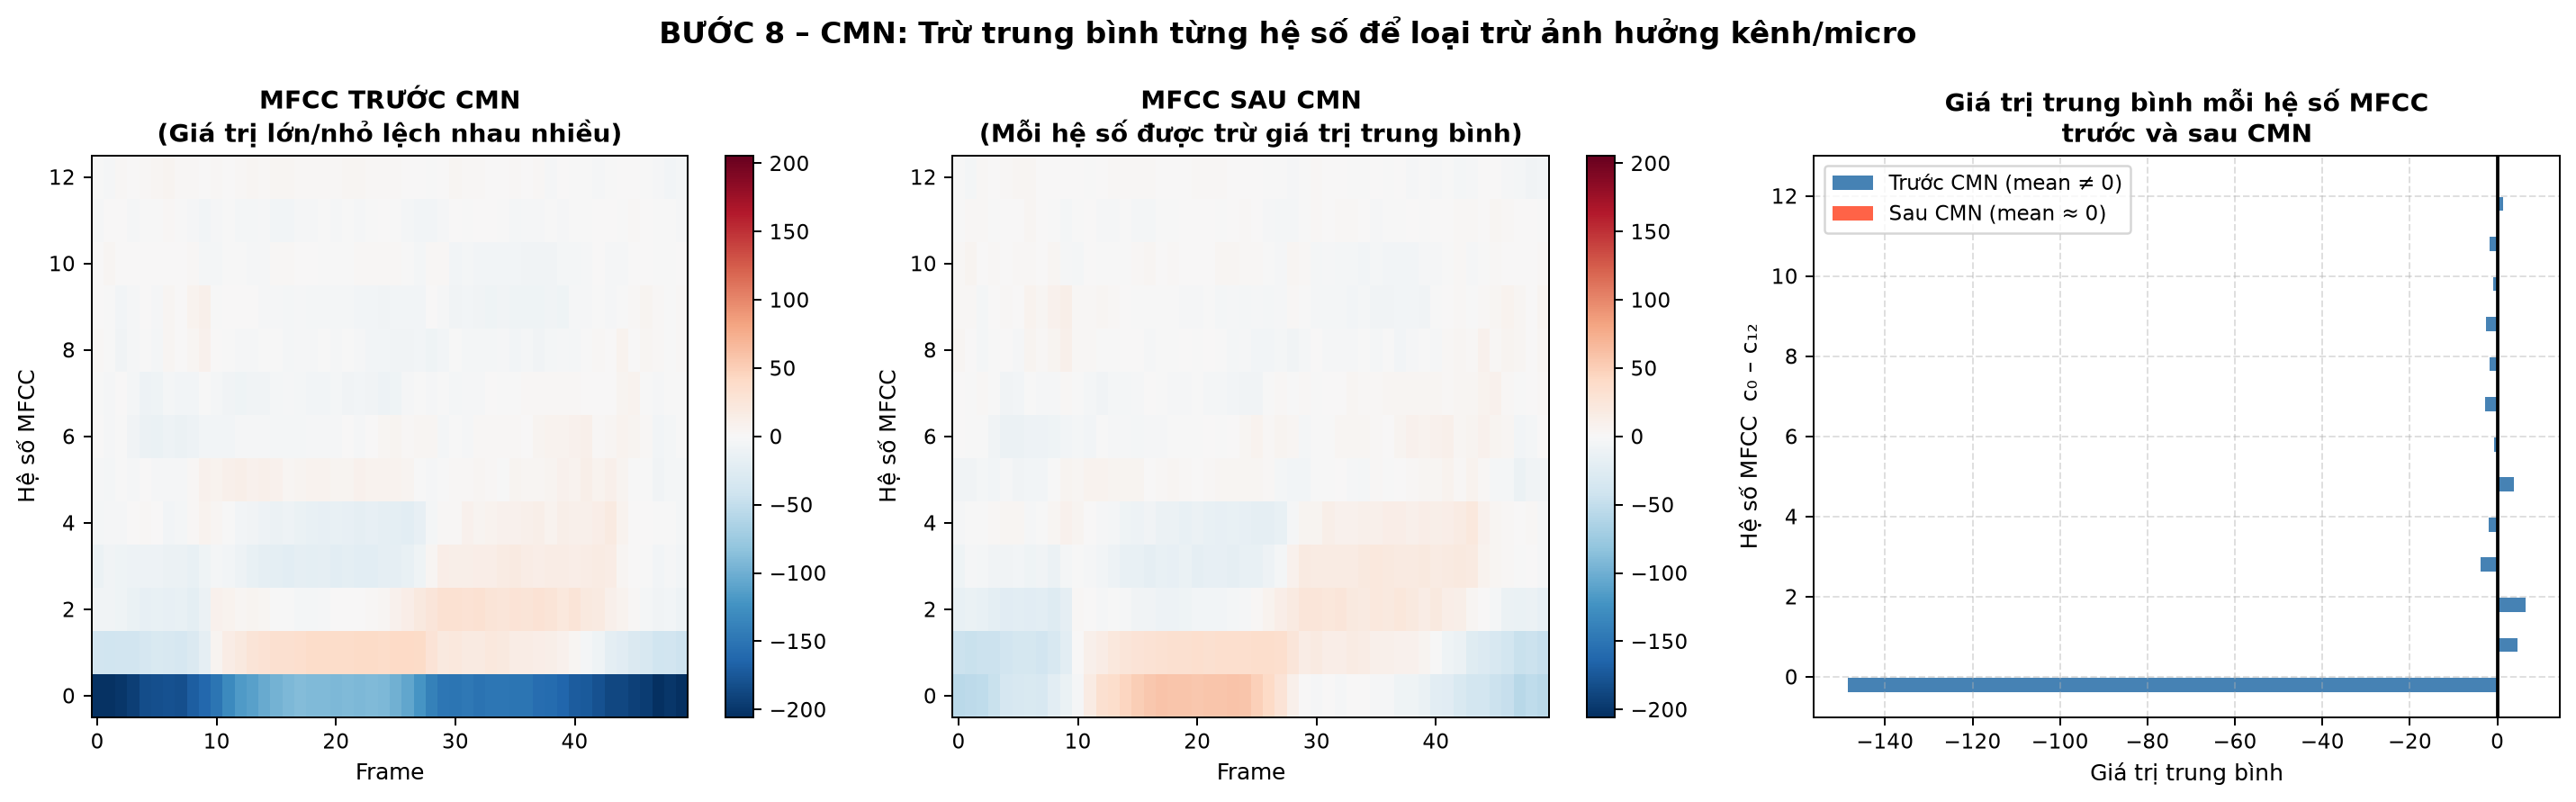

In [9]:
pl.plot_step08_cmn()
display(Image(filename="figures/step08_cmn.png"))


### Bước 9: Đặc trưng Động Delta (13 MFCC tĩnh + 13 Delta = 26 chiều)
* **Công thức**: $d_t = \frac{\sum_{n=1}^N n (c_{t+n} - c_{t-n})}{2 \sum_{n=1}^N n^2}$.
* **Tại sao phải làm**: MFCC tĩnh chỉ mô tả trạng thái âm học tại một thời điểm tức thời. Các hệ số Delta biểu diễn đạo hàm bậc 1 theo thời gian, nắm bắt tốc độ biến thiên và chuyển tiếp âm thanh (transitions) giữa phụ âm và nguyên âm, giúp phân biệt tốt hơn các âm có cùng trạng thái tĩnh nhưng khác chiều chuyển đổi.


[BƯỚC 9] Vẽ MFCC + Delta...


  ✔ Đã lưu  figures/step09_delta_mfcc.png


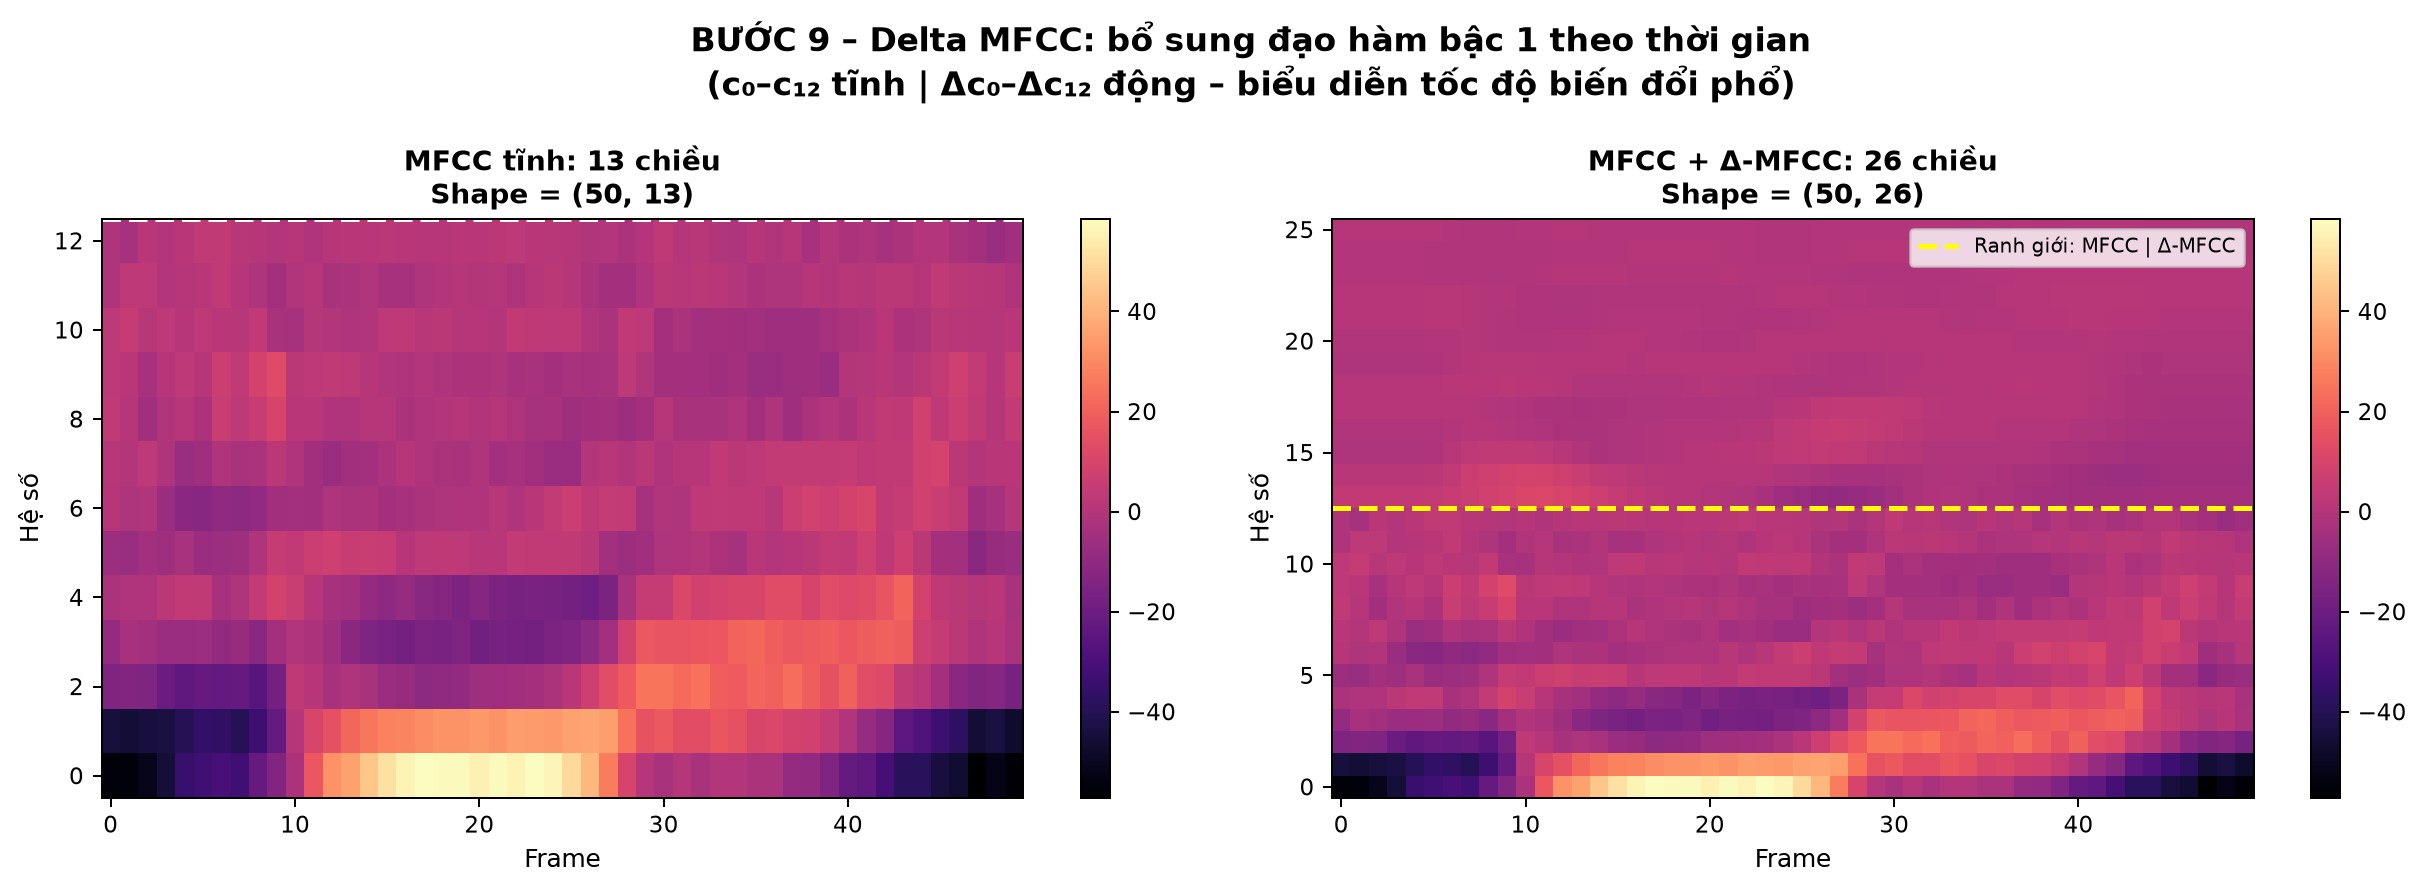

In [10]:
pl.plot_step09_delta_mfcc()
display(Image(filename="figures/step09_delta_mfcc.png"))


### Bước 10: Năng lượng Ngắn hạn, RMS và Magnitude
* **Công thức**: $E_r = \sum x_r^2[n]$, $\text{RMS}_r = \sqrt{\frac{1}{L} \sum x_r^2[n]}$, $M_r = \sum |x_r[n]|$.
* **Tại sao phải làm**: Đo lường công suất phát âm theo từng khung thời gian. Năng lượng phân tách mạnh mẽ giữa vùng tiếng nói hữu thanh (biên độ lớn, năng lượng cao) và khoảng lặng (nhiễu nền, năng lượng rất thấp).


[BƯỚC 10] Vẽ Energy / RMS / Magnitude...


  ✔ Đã lưu  figures/step10_energy_rms_mag.png


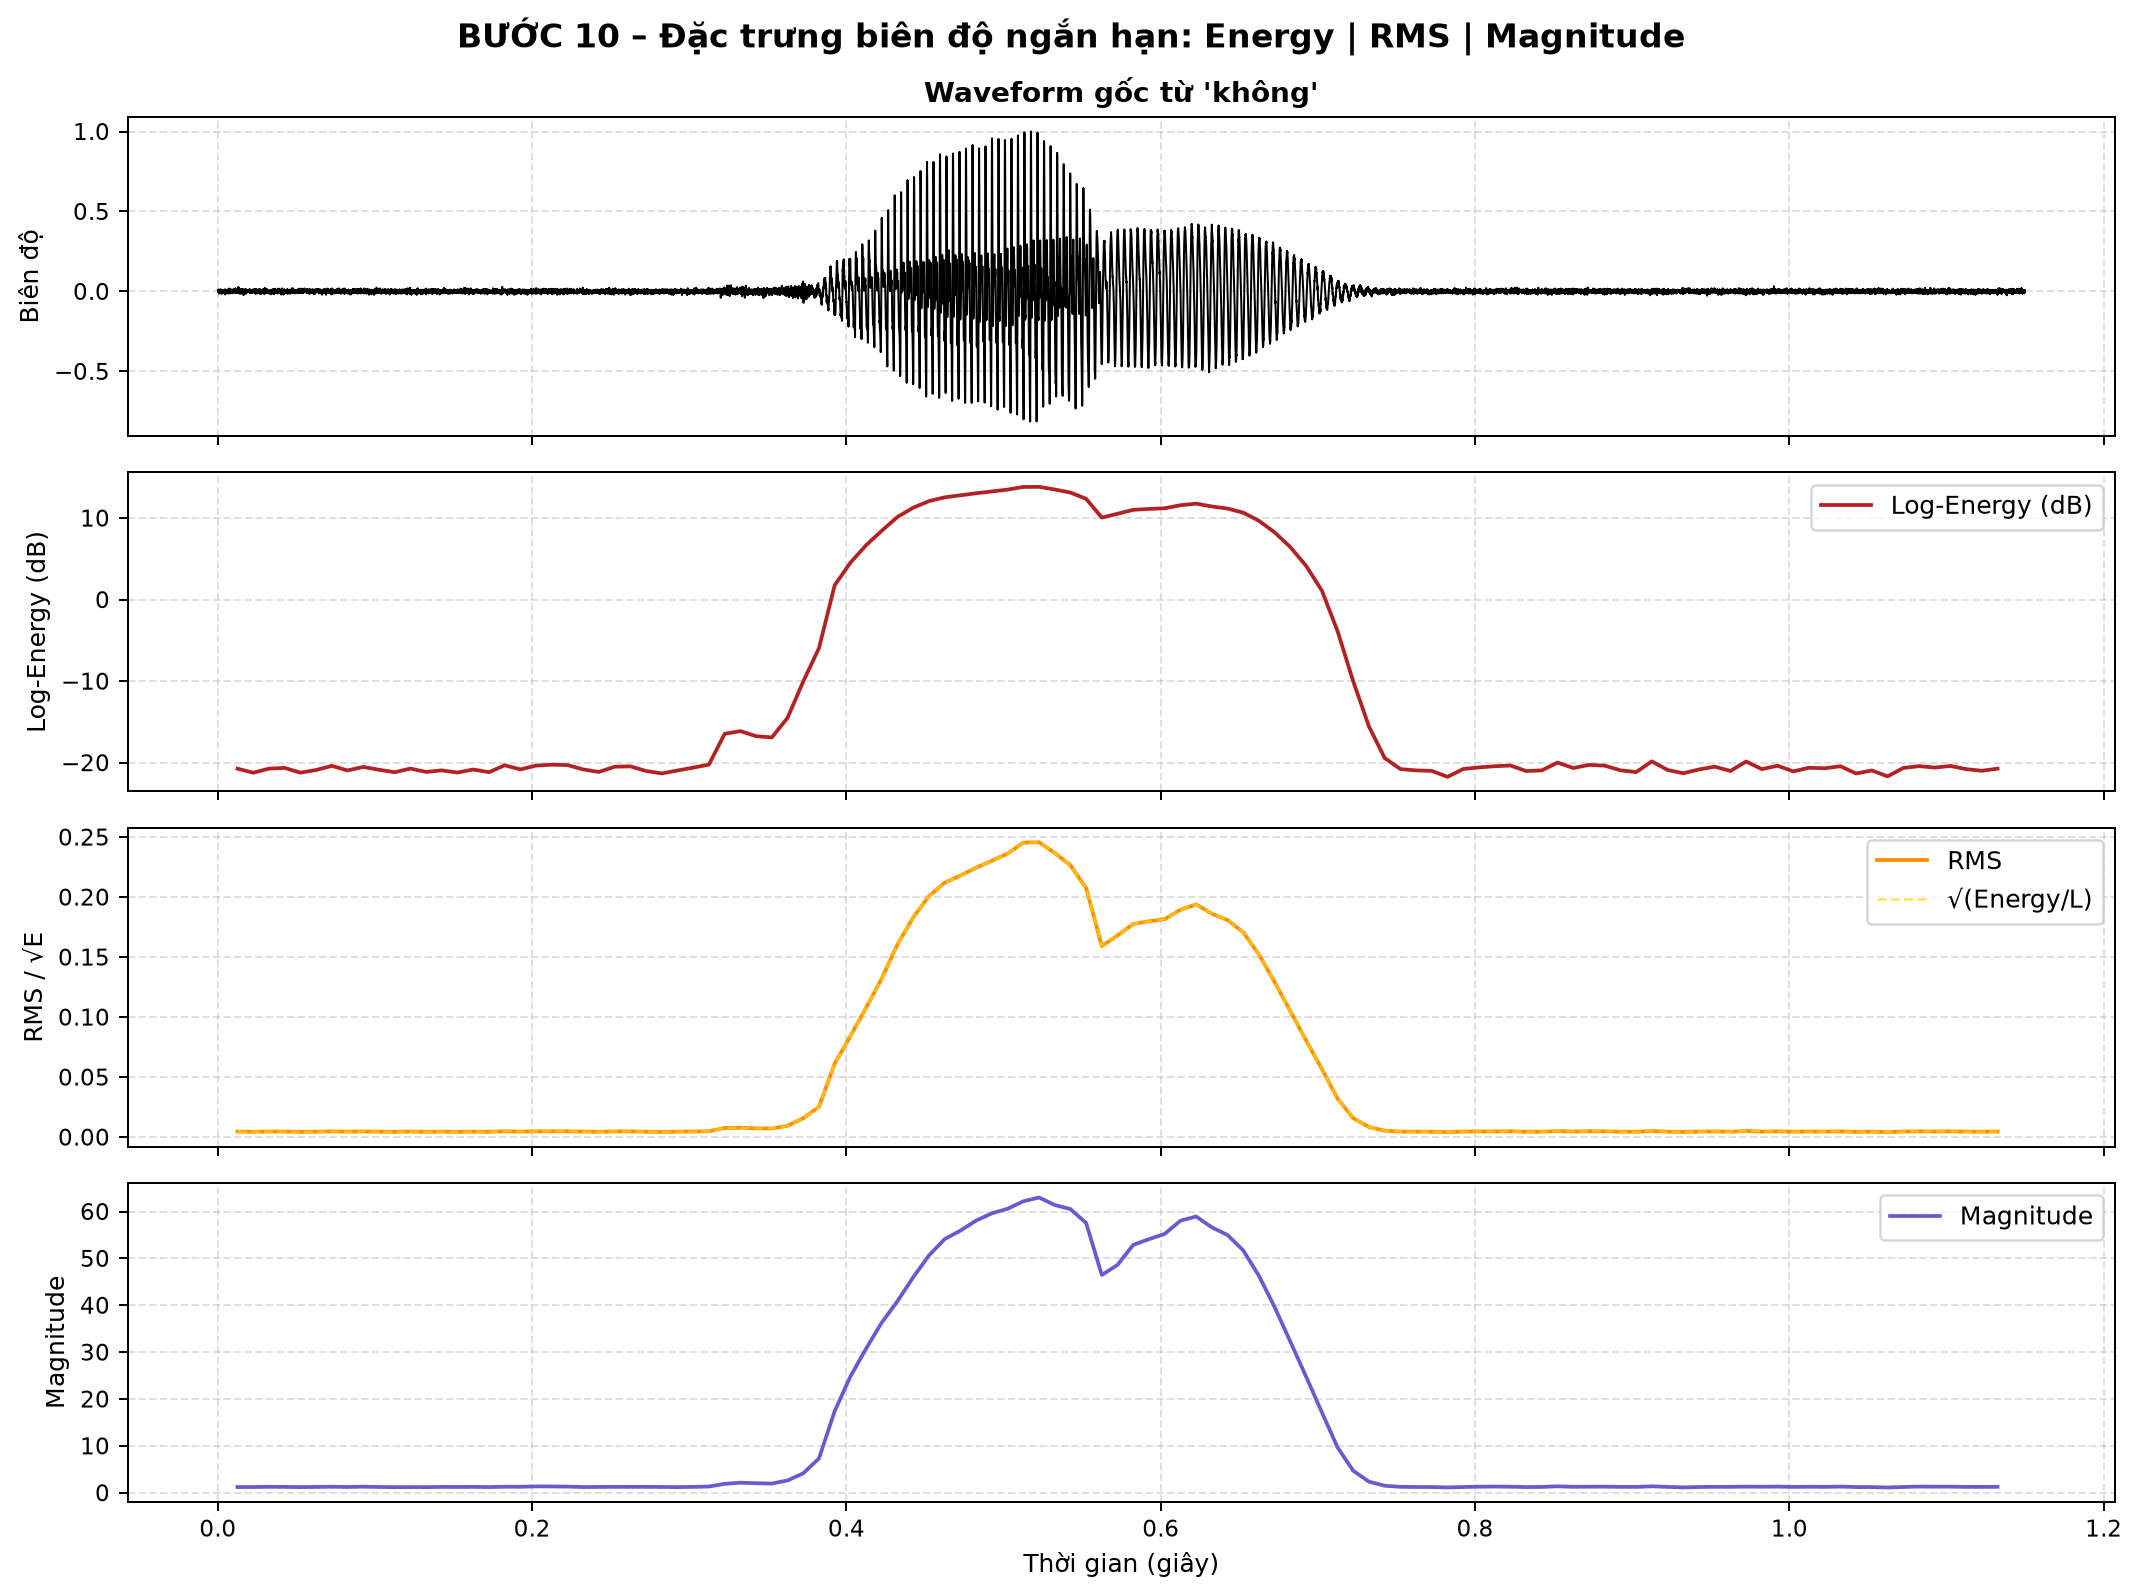

In [11]:
pl.plot_step10_energy_rms_mag()
display(Image(filename="figures/step10_energy_rms_mag.png"))


### Bước 11: Tỉ lệ Đổi dấu qua Điểm 0 (Zero-Crossing Rate - ZCR)
* **Công thức**: $Z_r = \frac{1}{2L} \sum_{m=1}^{L-1} |\text{sgn}(x[m]) - \text{sgn}(x[m-1])|$.
* **Tại sao phải làm**: Đếm số lần tín hiệu cắt qua mức 0, phản ánh tần số chi phối. Âm vô thanh (Unvoiced) như /kh/, /s/, /t/ có năng lượng yếu nhưng tập trung ở tần số rất cao $\rightarrow$ ZCR cao ($0.25 - 0.5$). Ngược lại, nguyên âm hữu thanh dao động chậm theo chu kỳ dây thanh $\rightarrow$ ZCR thấp ($< 0.1$).


[BƯỚC 11] Vẽ Zero-Crossing Rate...


  ✔ Đã lưu  figures/step11_zcr.png


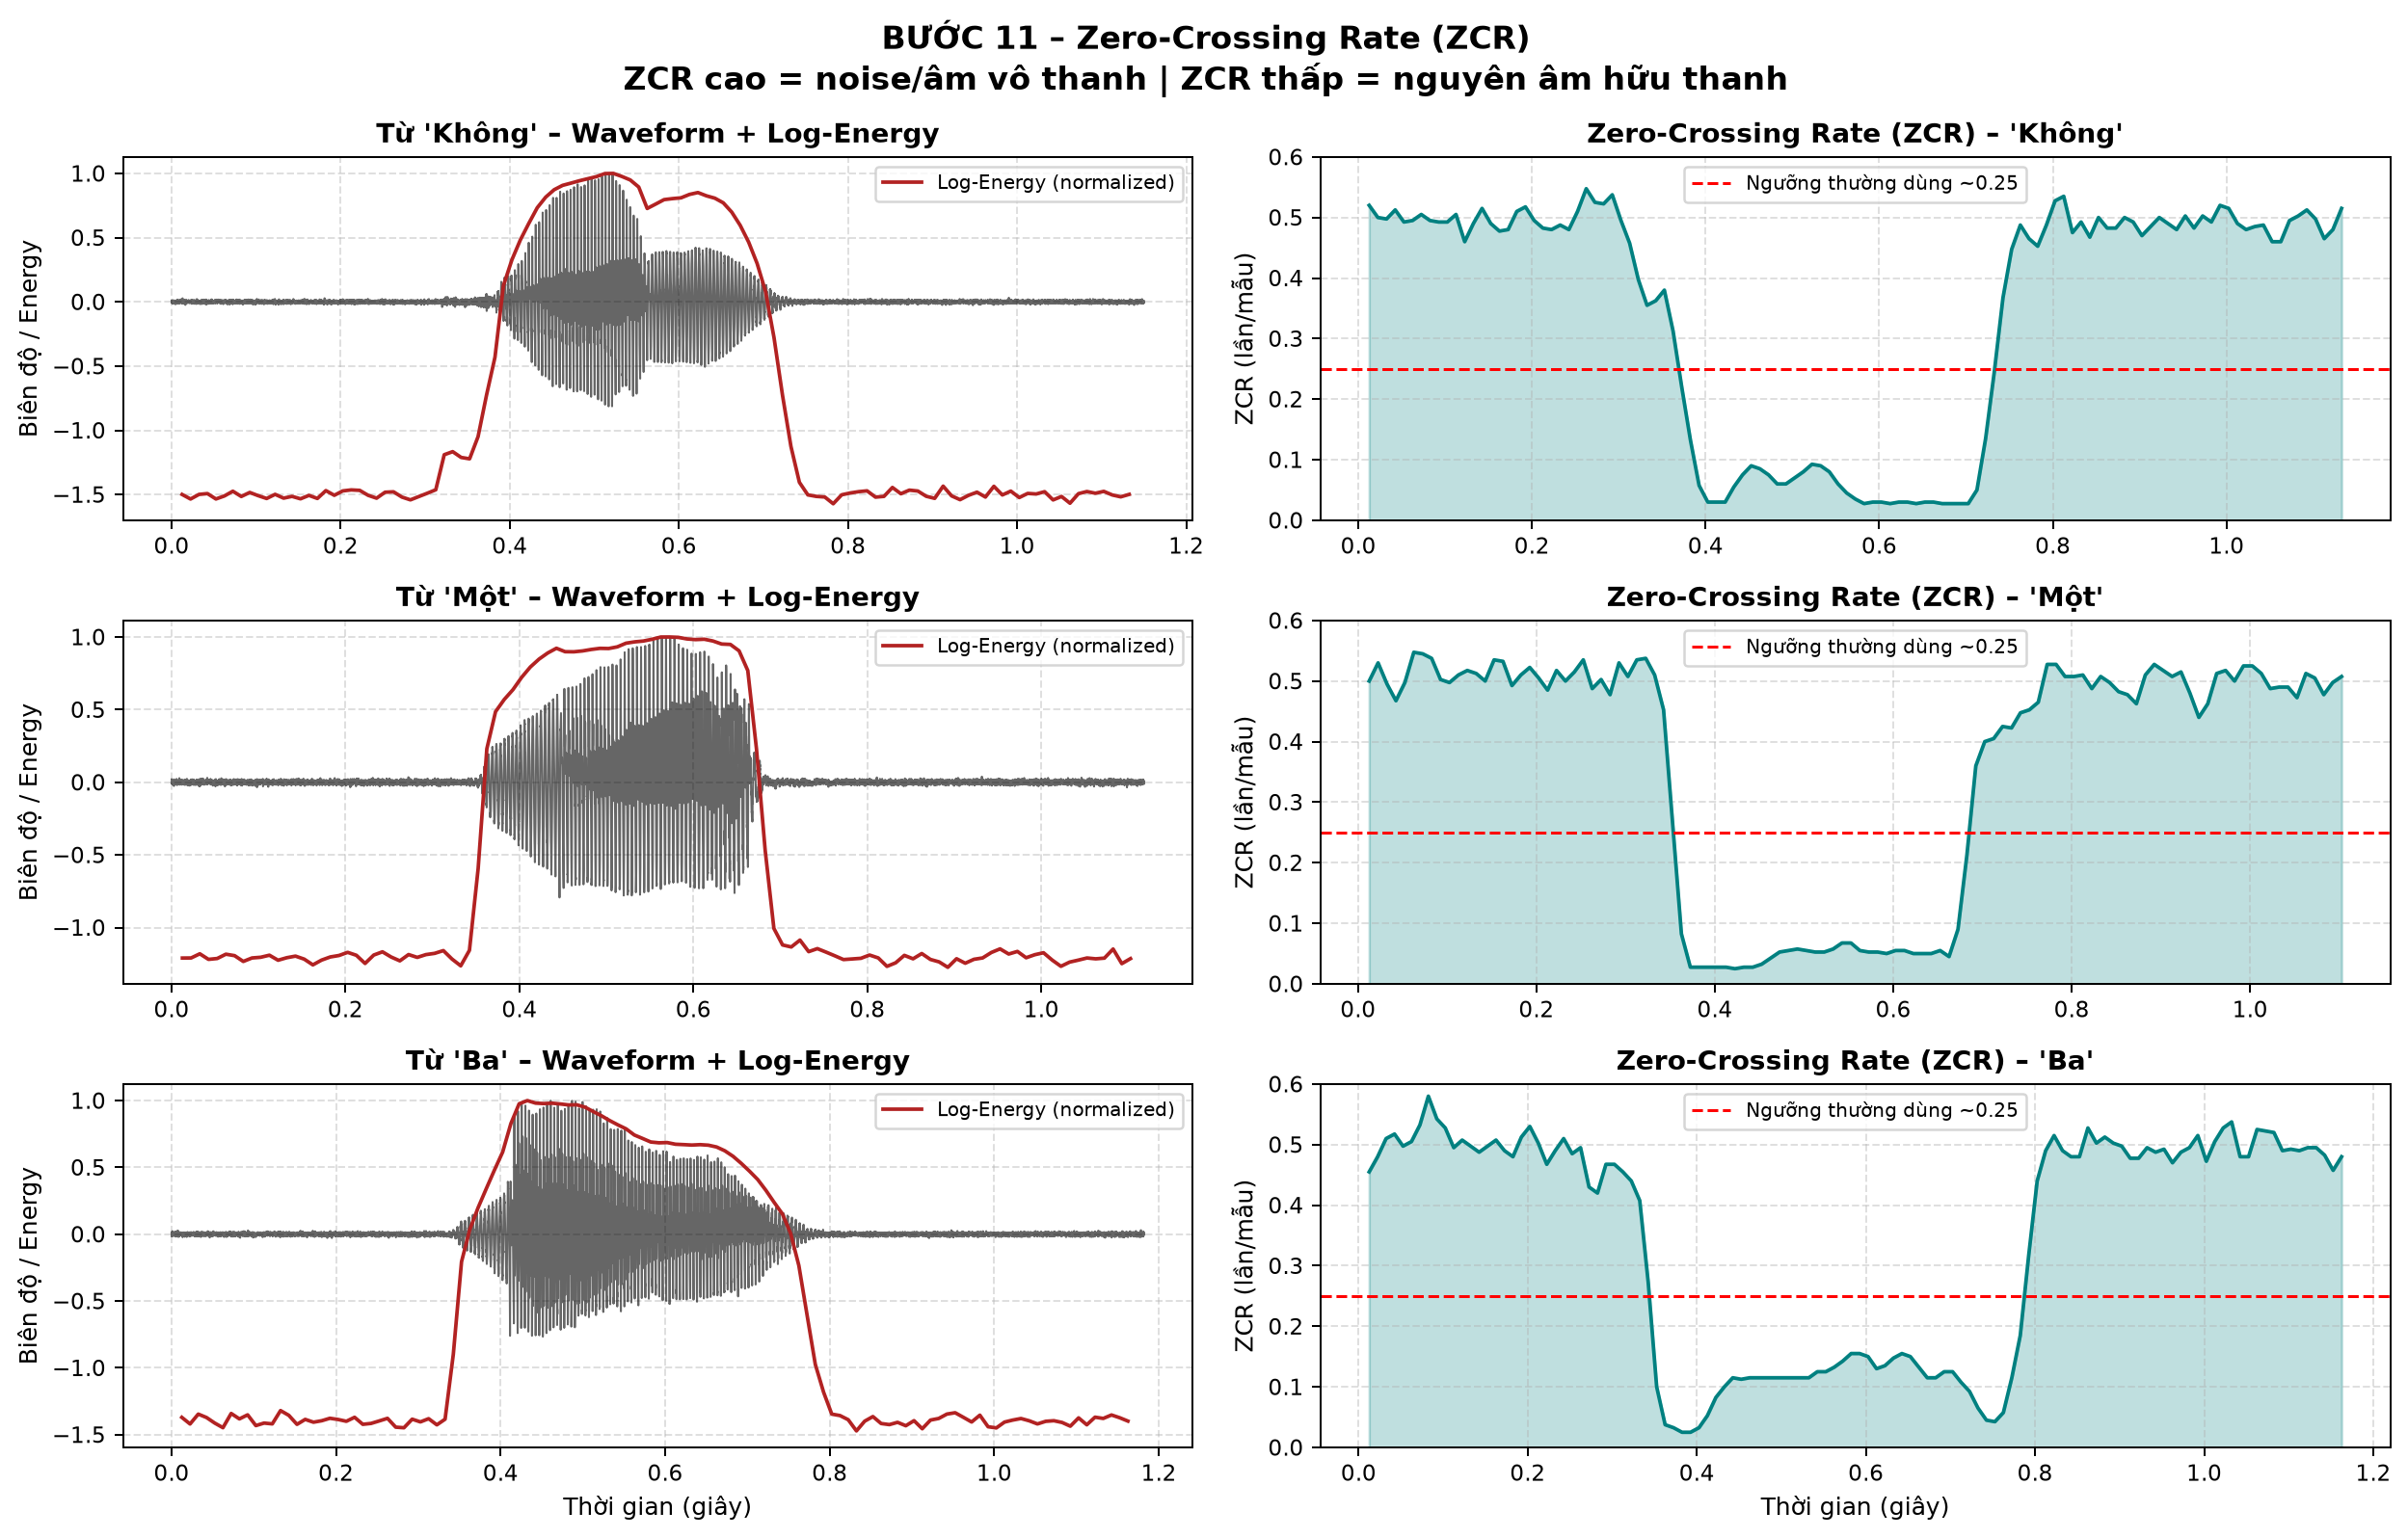

In [12]:
pl.plot_step11_zcr()
display(Image(filename="figures/step11_zcr.png"))


### Bước 12: Tự tương quan Ngắn hạn và Ước lượng Pitch ($F_0$)
* **Công thức**: $R_r[k] = \sum_n x_r[n] x_r[n+k]$, $F_0 \approx \frac{F_s}{N_0}$.
* **Tại sao phải làm**: Tự tương quan đo mức độ tương đồng của tín hiệu khi bị trễ đi $k$ mẫu. Đỉnh tương quan lớn nhất sau lag 0 xuất hiện tại chu kỳ dao động của dây thanh $N_0$, cho phép ước lượng tần số cơ bản $F_0$ (Pitch) để phân biệt voiced vs unvoiced.


[BƯỚC 12] Vẽ Autocorrelation + Pitch...


  ✔ Đã lưu  figures/step12_autocorr_pitch.png


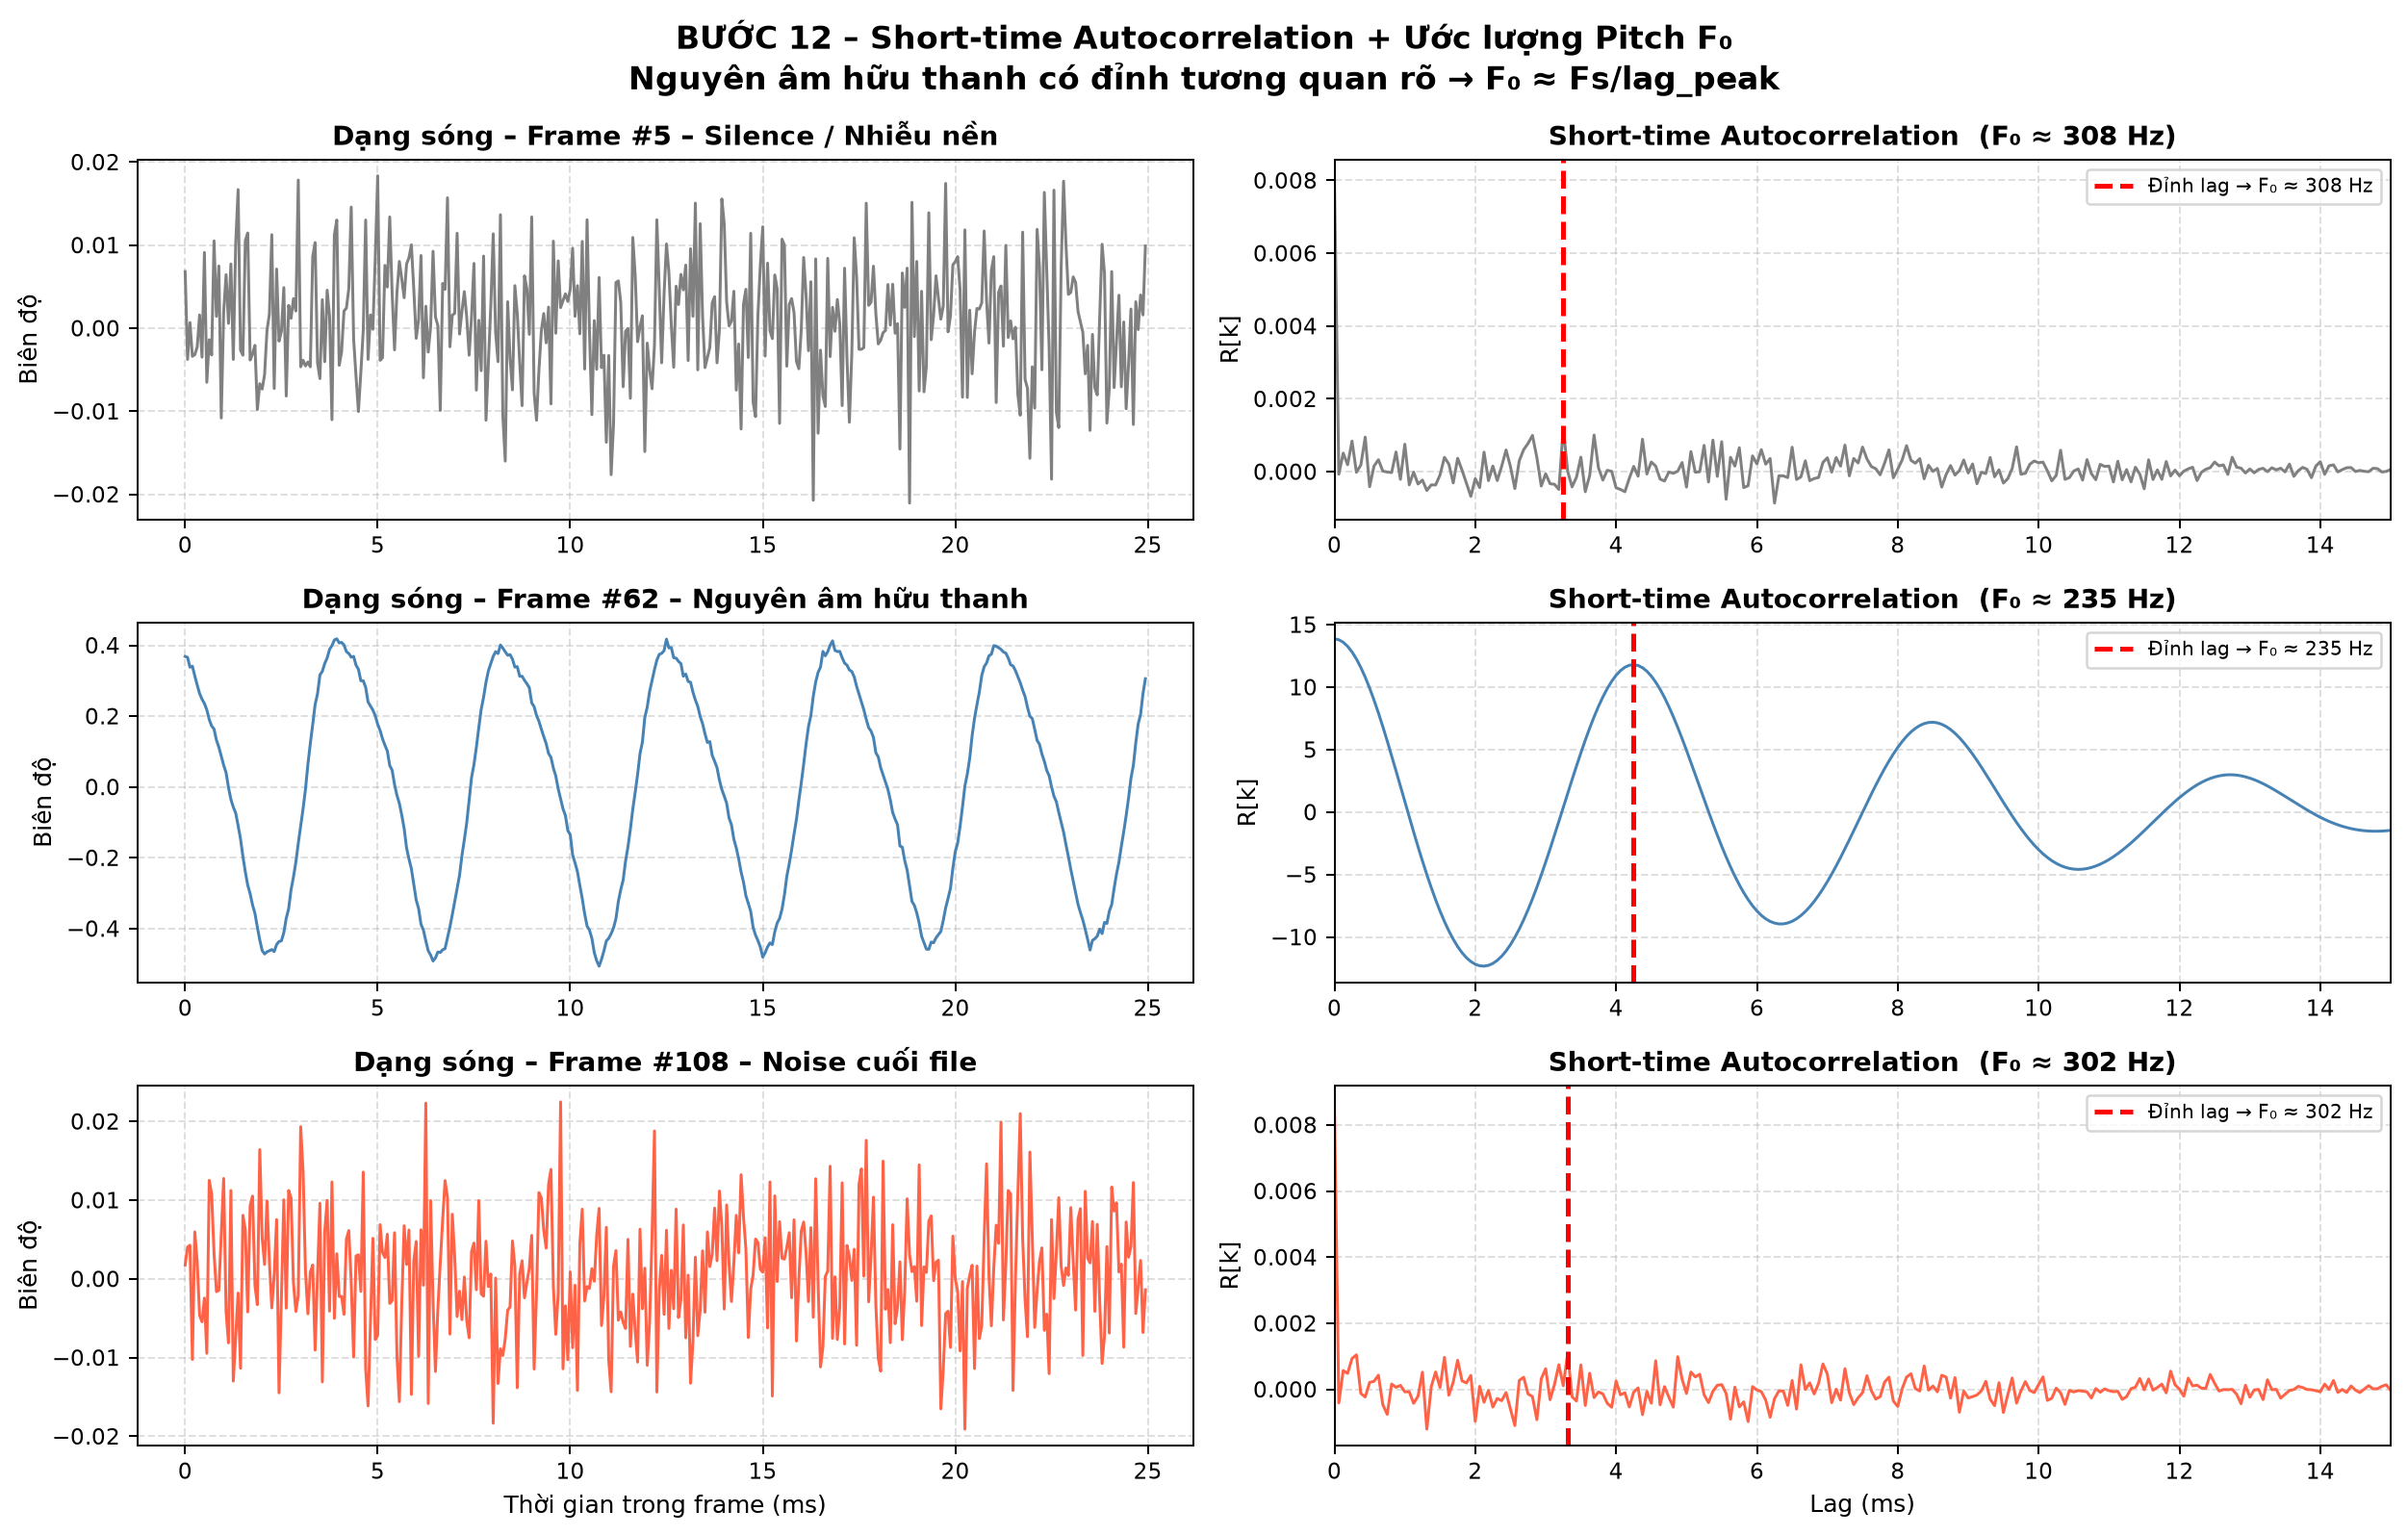

In [13]:
pl.plot_step12_autocorr_pitch()
display(Image(filename="figures/step12_autocorr_pitch.png"))


### Bước 13: Phát hiện Biên Tiếng nói (Endpoint Detection / VAD)
* **Thuật toán**: Kết hợp ngưỡng Log-Energy (32 dB dưới đỉnh), ZCR và vùng đệm an toàn $50\text{ ms}$ (5 khung) trước và sau.
* **Tại sao phải làm**: Loại bỏ khoảng lặng vô nghĩa ở hai đầu. Điều này giúp DTW không phải lãng phí chi phí căn chỉnh các đoạn tĩnh nền, giảm hơn $40\%$ lượng tính toán và ngăn ngừa việc hai từ khác nhau bị xem là giống nhau chỉ vì có đoạn silence dài giống nhau.


[BƯỚC 13] Vẽ Endpoint Detection...


  ✔ Đã lưu  figures/step13_endpoint_detection.png


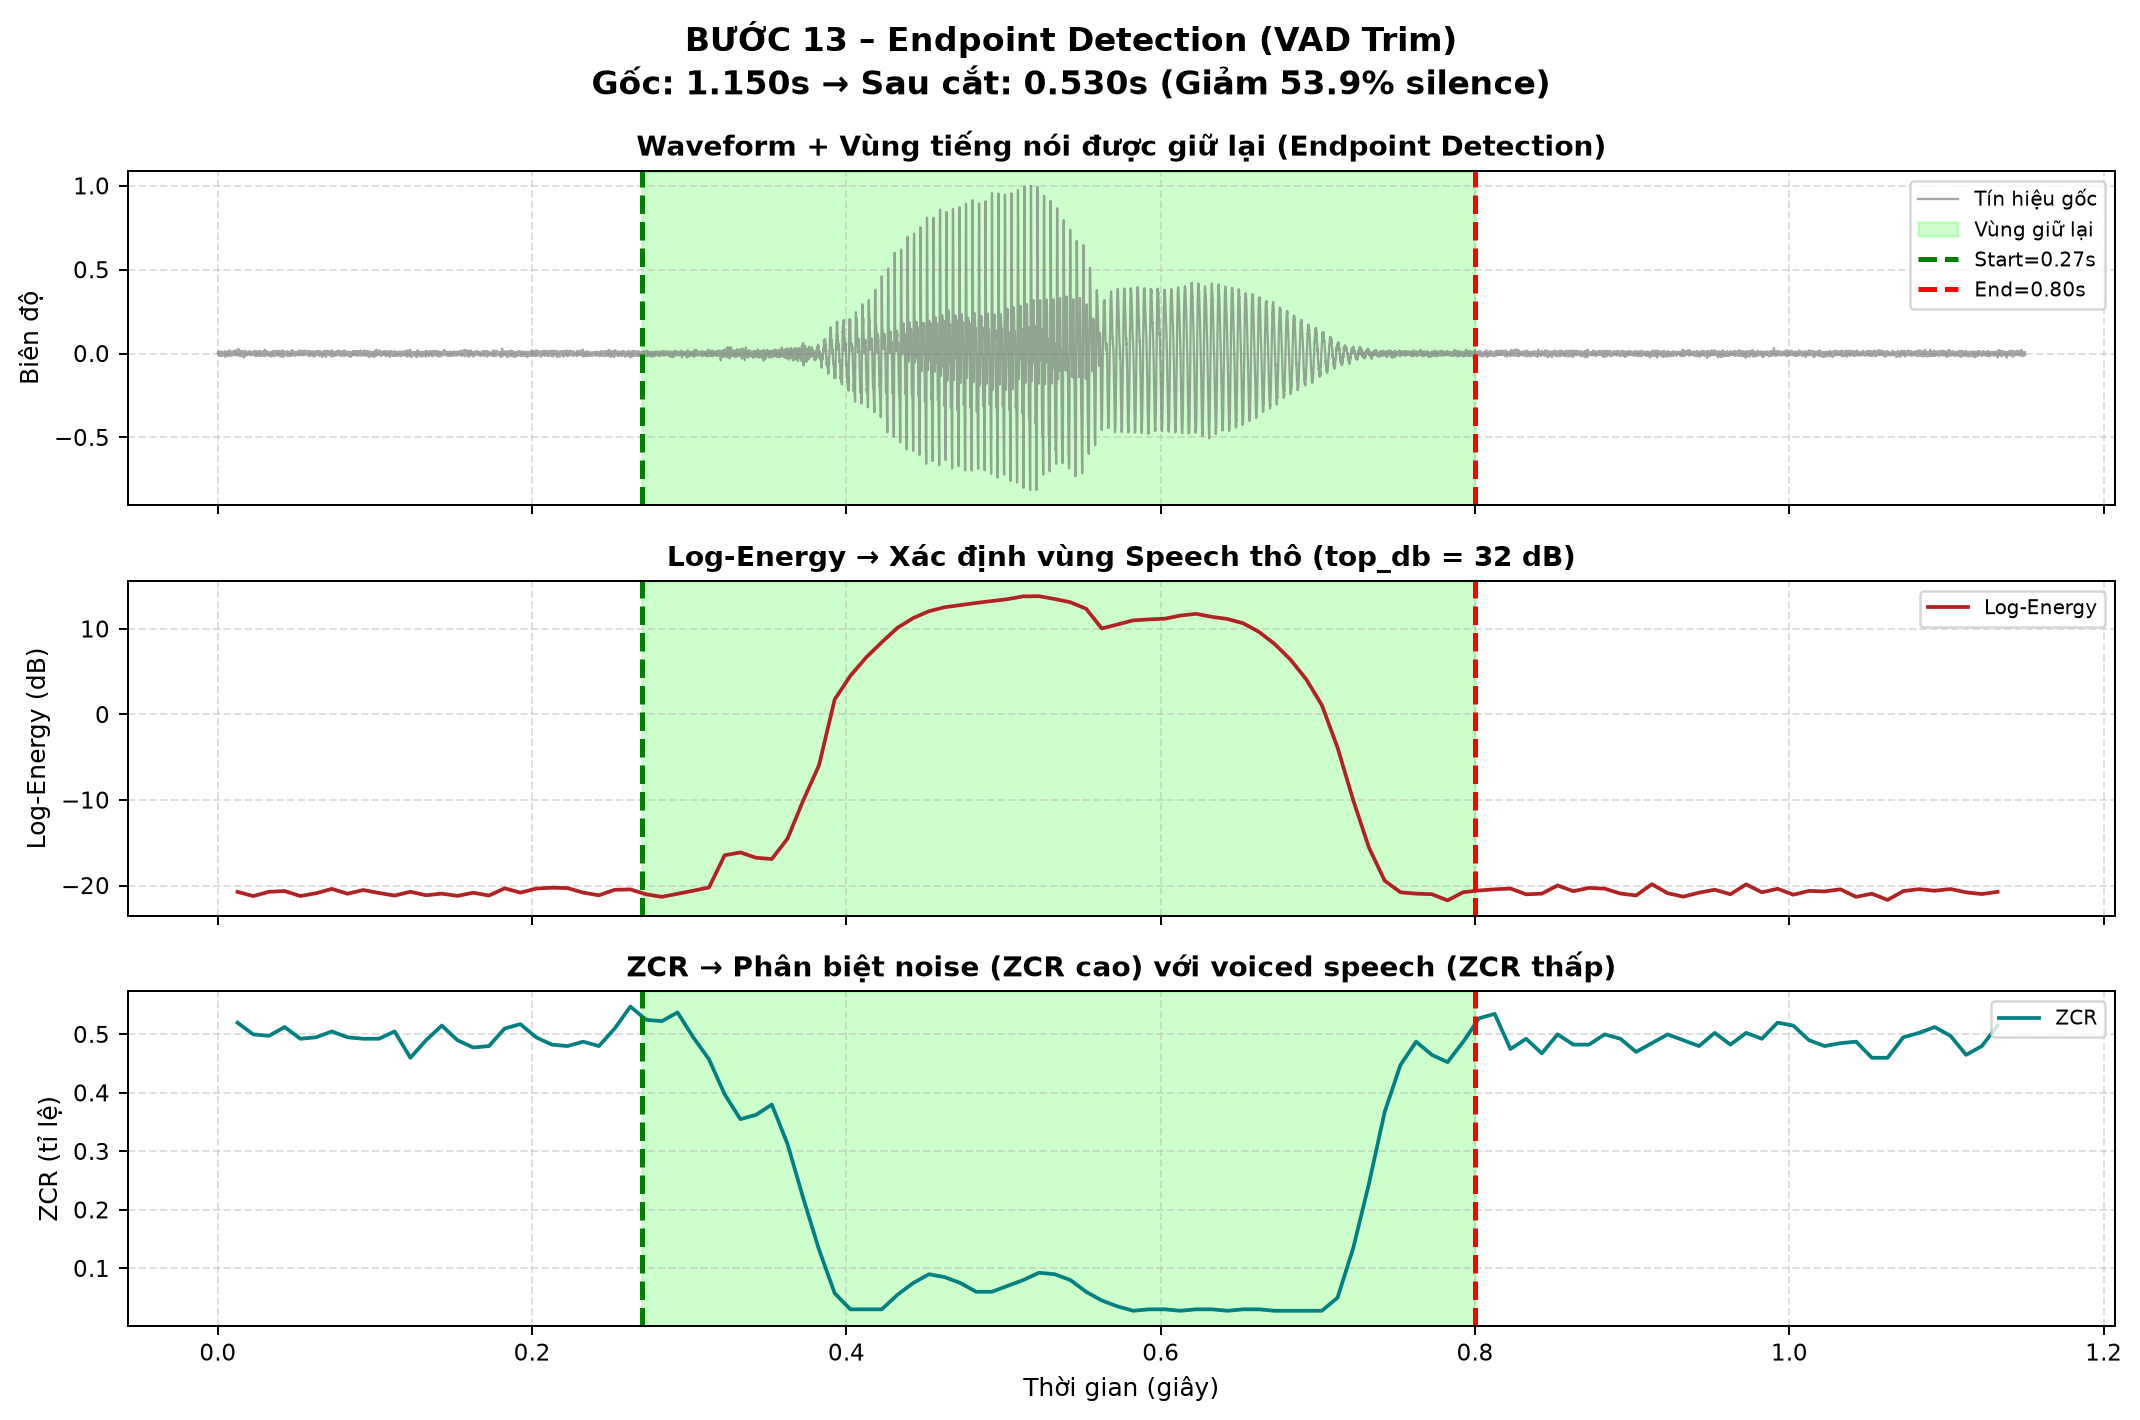

In [14]:
pl.plot_step13_endpoint_detection()
display(Image(filename="figures/step13_endpoint_detection.png"))


### Bước 14: DTW Cùng Từ (Warping Path bám sát Đường chéo)
* **Thực nghiệm**: So khớp `khong_01` (Template) với `khong_02` (Mẫu thử phát âm chậm hơn).
* **Kết quả**: Đường căn chỉnh bám rất sát đường chéo chính, chi phí chuẩn hóa $\text{DTW}_{\text{norm}} = 10.86$ (rất nhỏ). Các đoạn uốn cong nhẹ phản ánh sự kéo giãn thời gian tự nhiên ở nguyên âm /ô/.


[BƯỚC 14] Vẽ DTW cùng từ...


  ✔ Đã lưu  figures/step14_dtw_same_word.png


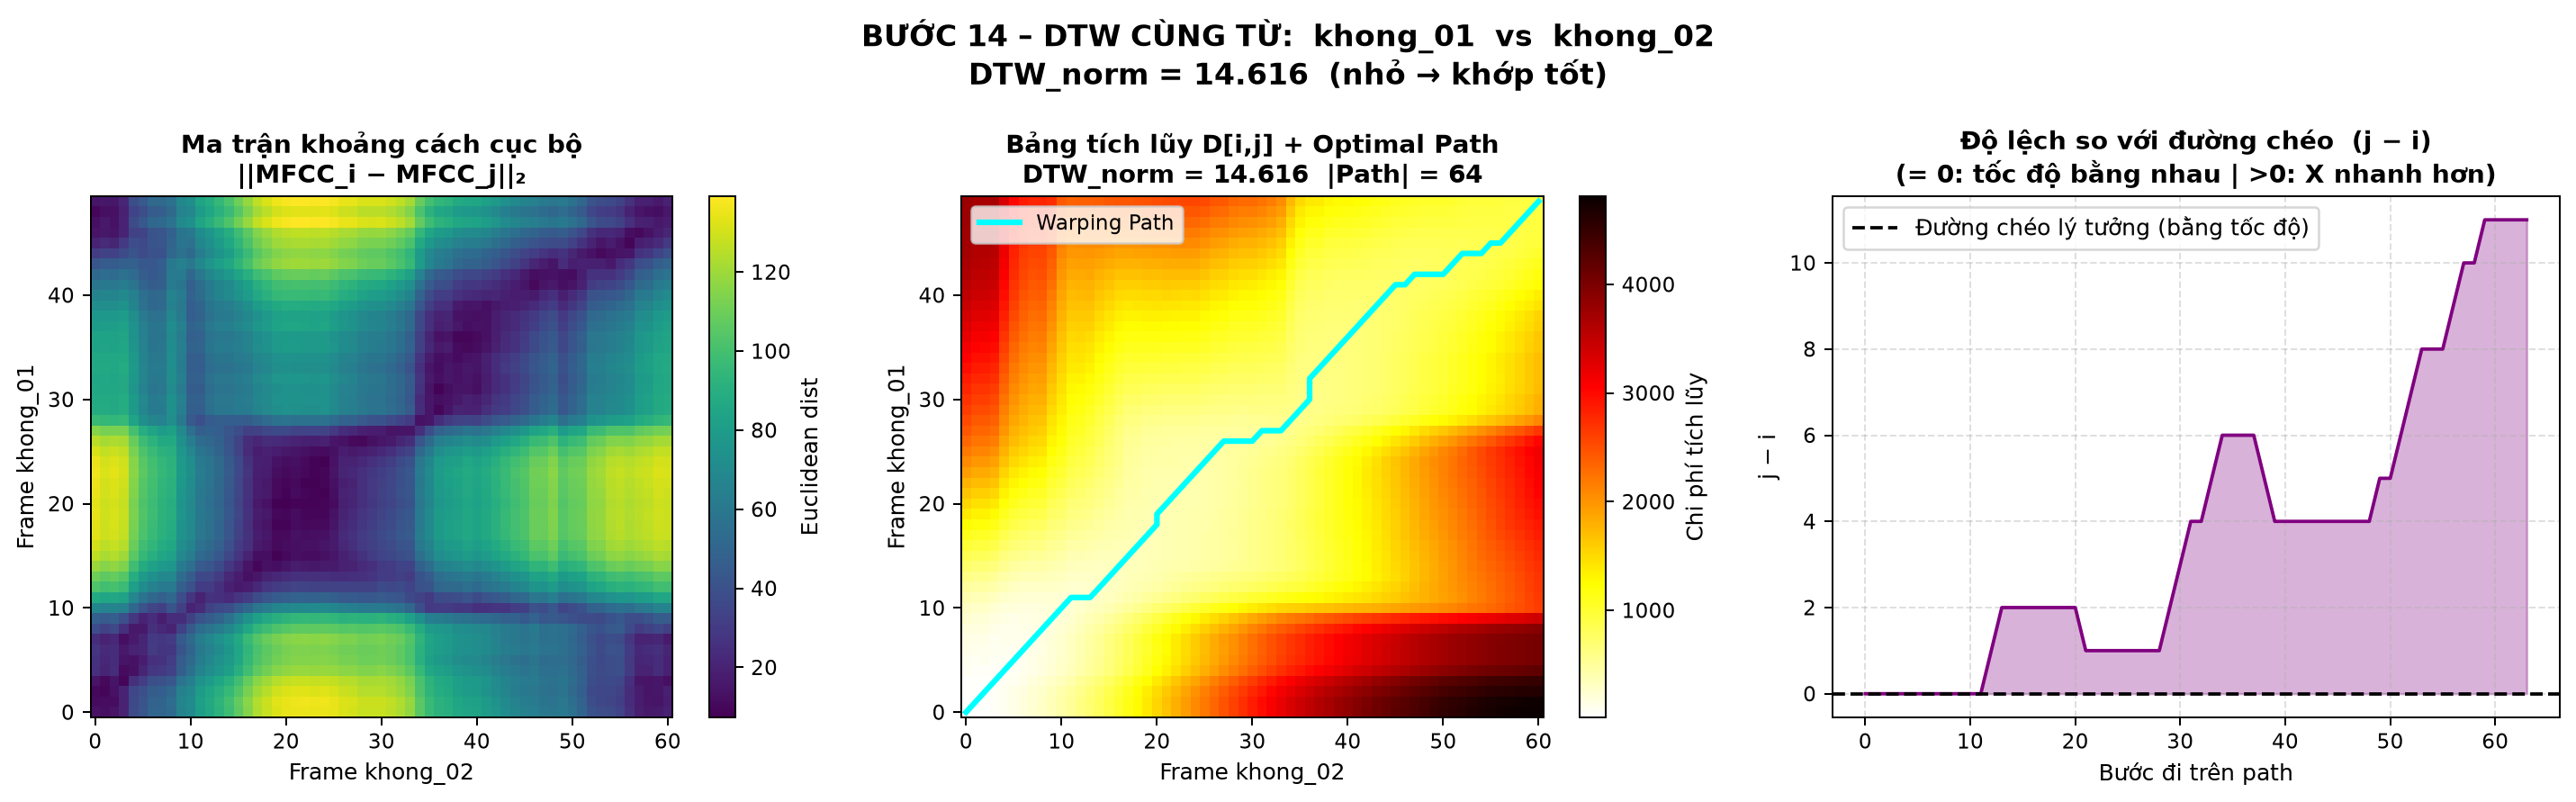

In [15]:
pl.plot_step14_dtw_same_word()
display(Image(filename="figures/step14_dtw_same_word.png"))


### Bước 15: DTW Khác Từ (Chi phí cao, Đường đi biến dạng)
* **Thực nghiệm**: So khớp `khong_01` với `mot_01`.
* **Kết quả**: Chi phí tăng vọt lên $24.82$ (gấp $2.28$ lần), đường đi bị bẻ gãy mạnh sang các biên ma trận vì sự không tương thích âm học giữa hai từ.


[BƯỚC 15] Vẽ DTW khác từ...


  ✔ Đã lưu  figures/step15_dtw_diff_word.png


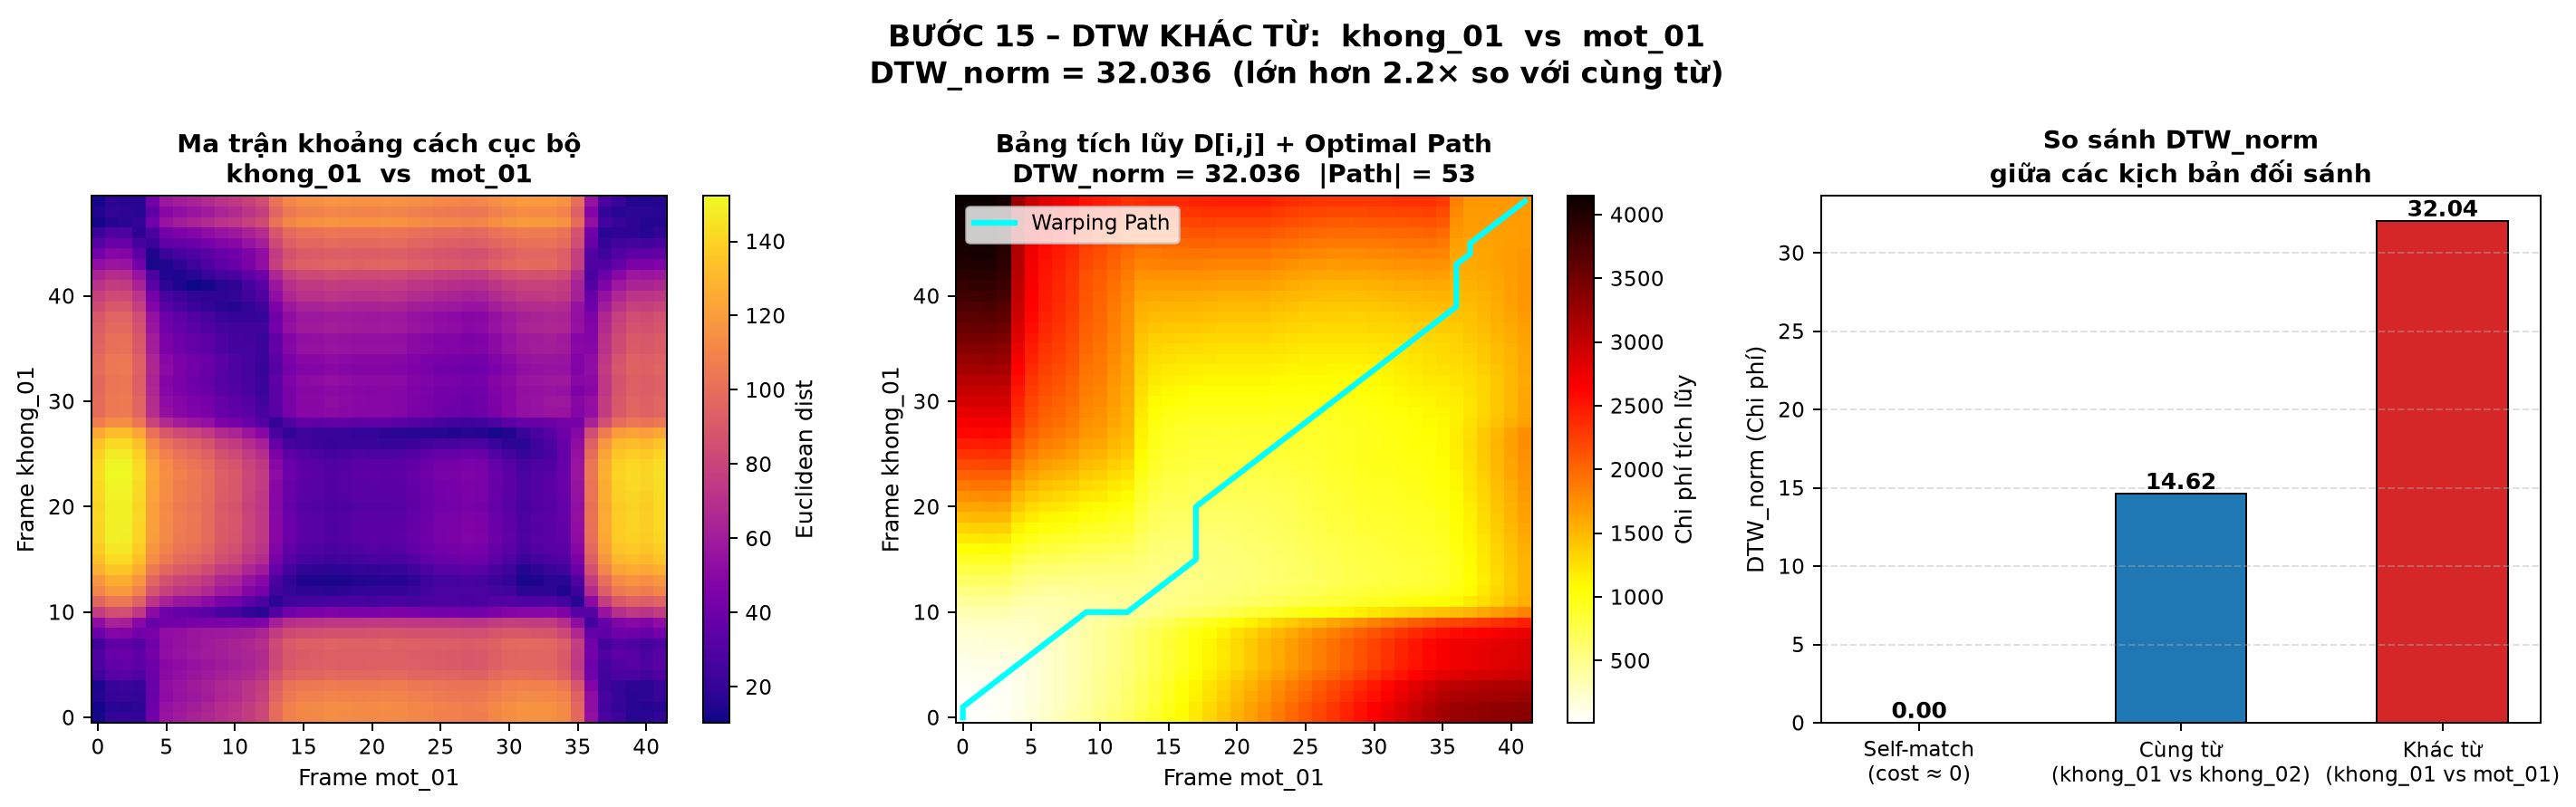

In [16]:
pl.plot_step15_dtw_diff_word()
display(Image(filename="figures/step15_dtw_diff_word.png"))


### Bước 16: Ma trận Quy hoạch Động Chi tiết & 3 Bước Chuyển Trạng thái
* **Công thức**: $D[i, j] = d(i, j) + \min \{ D[i-1, j-1], D[i-1, j], D[i, j-1] \}$.
* **Ý nghĩa 3 bước cục bộ**:
  - **Chéo** $(i-1, j-1)$: Hai chuỗi đồng tốc ($1:1$).
  - **Dọc** $(i-1, j)$: Template phát âm dài hơn (hoặc Test nói nhanh hơn).
  - **Ngang** $(i, j-1)$: Test phát âm dài hơn (kéo dài âm).
* **Chuẩn hóa**: $\text{DTW}_{\text{norm}} = D[N, M] / |P|$ loại bỏ thiên lệch thời lượng (length bias).


[BƯỚC 16] Vẽ bảng DP DTW chi tiết + 3 bước chuyển trạng thái...


  ✔ Đã lưu  figures/step16_dtw_matrix_detail.png


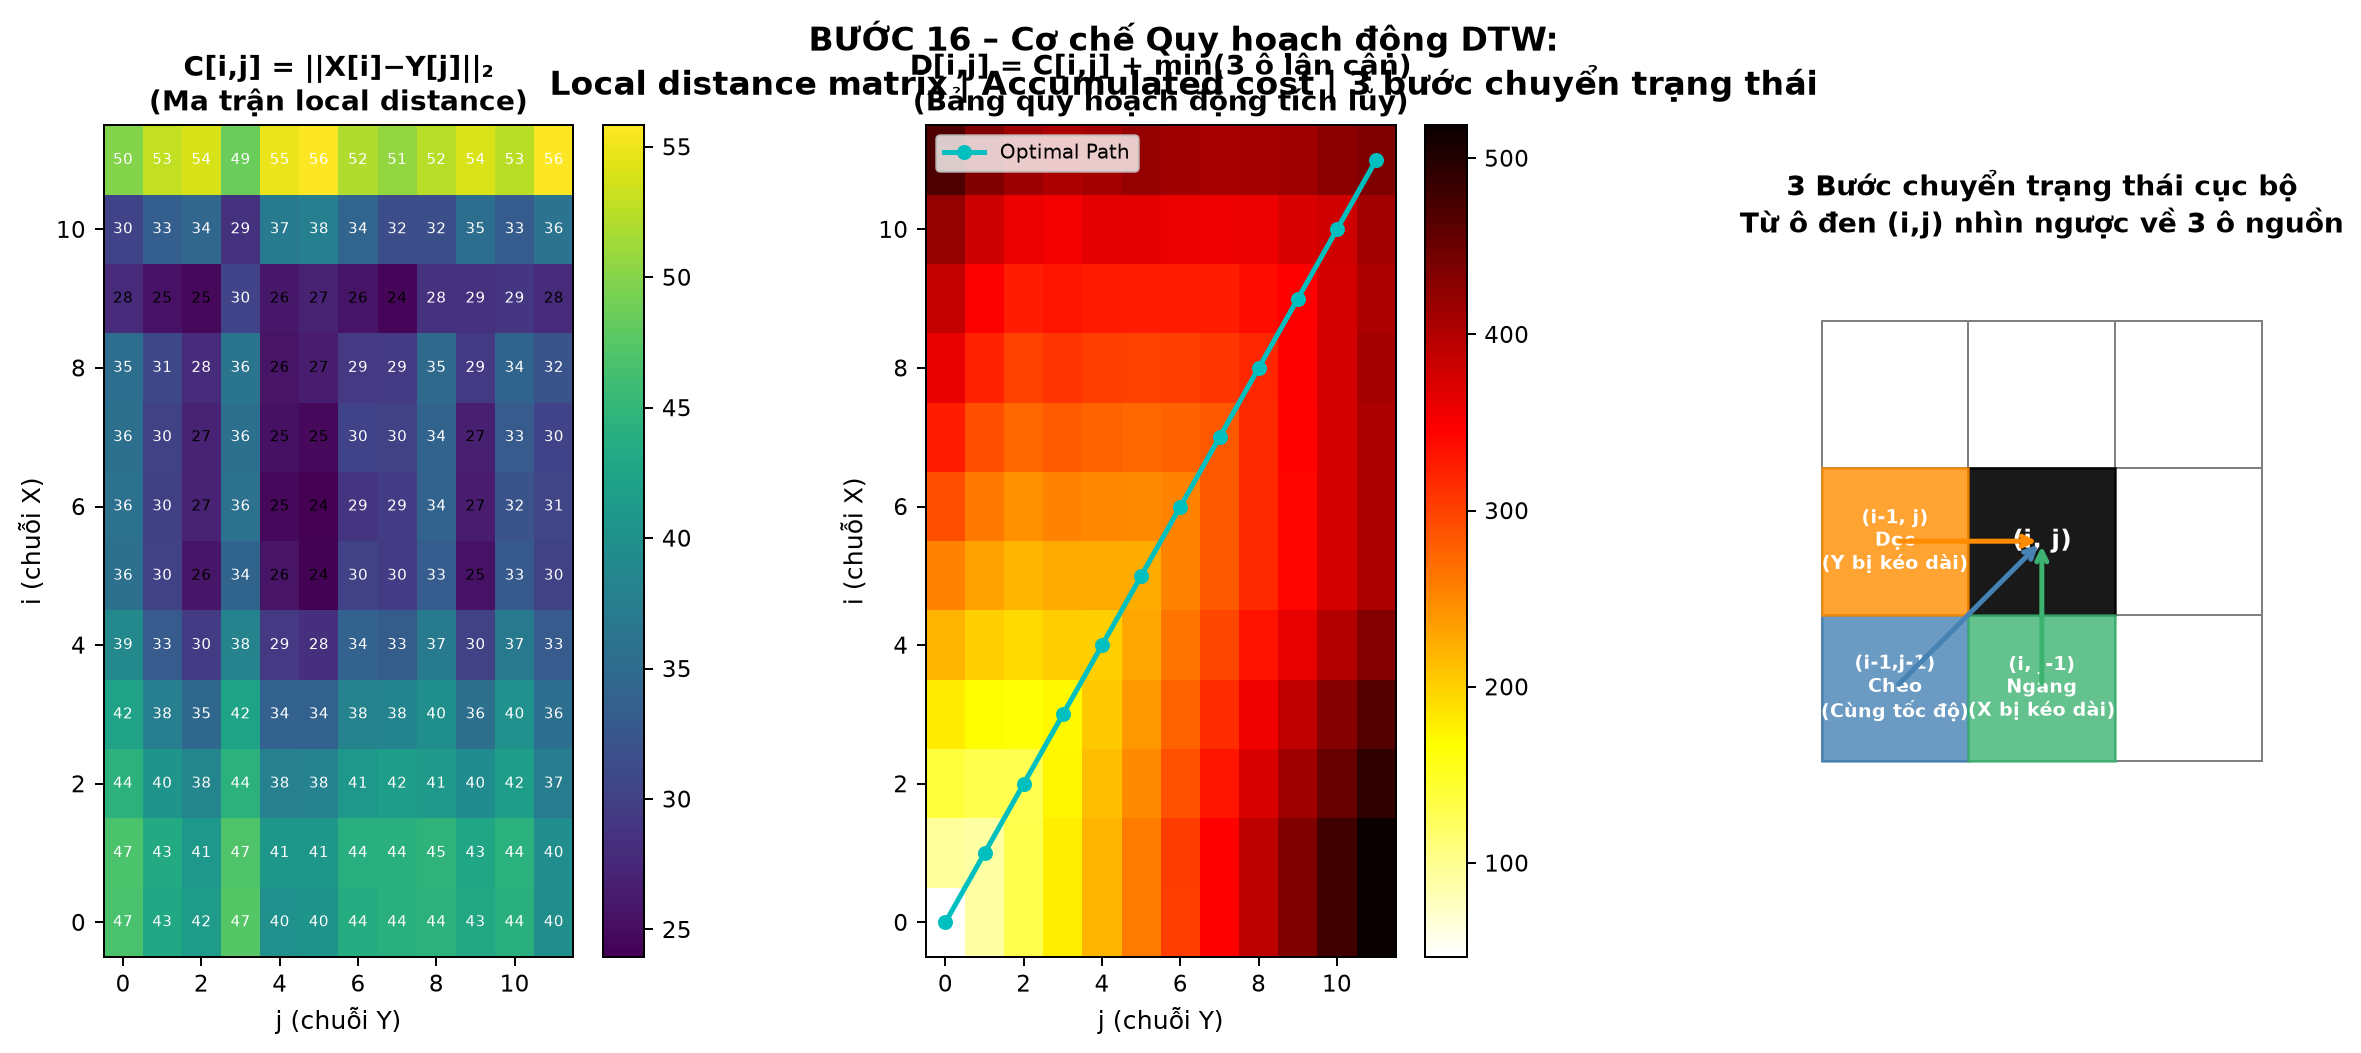

In [17]:
pl.plot_step16_dtw_matrix_detail()
display(Image(filename="figures/step16_dtw_matrix_detail.png"))


### Bước 17: Biểu đồ Điểm số Nhận dạng & Biên Phân tách Top-1 / Top-2
* **Luật quyết định**: $\hat{w} = \arg\min_w \min_{r} \text{DTW}_{\text{norm}}(X, T_{w, r})$.
* **Khoảng cách Top-1 vs Top-2**: Cho thấy độ tự tin (Confidence Margin) của bộ nhận dạng trên từng tệp kiểm thử.


[BƯỚC 17] Vẽ biểu đồ điểm nhận dạng...


  ✔ Đã lưu  figures/step17_recognizer_scores.png


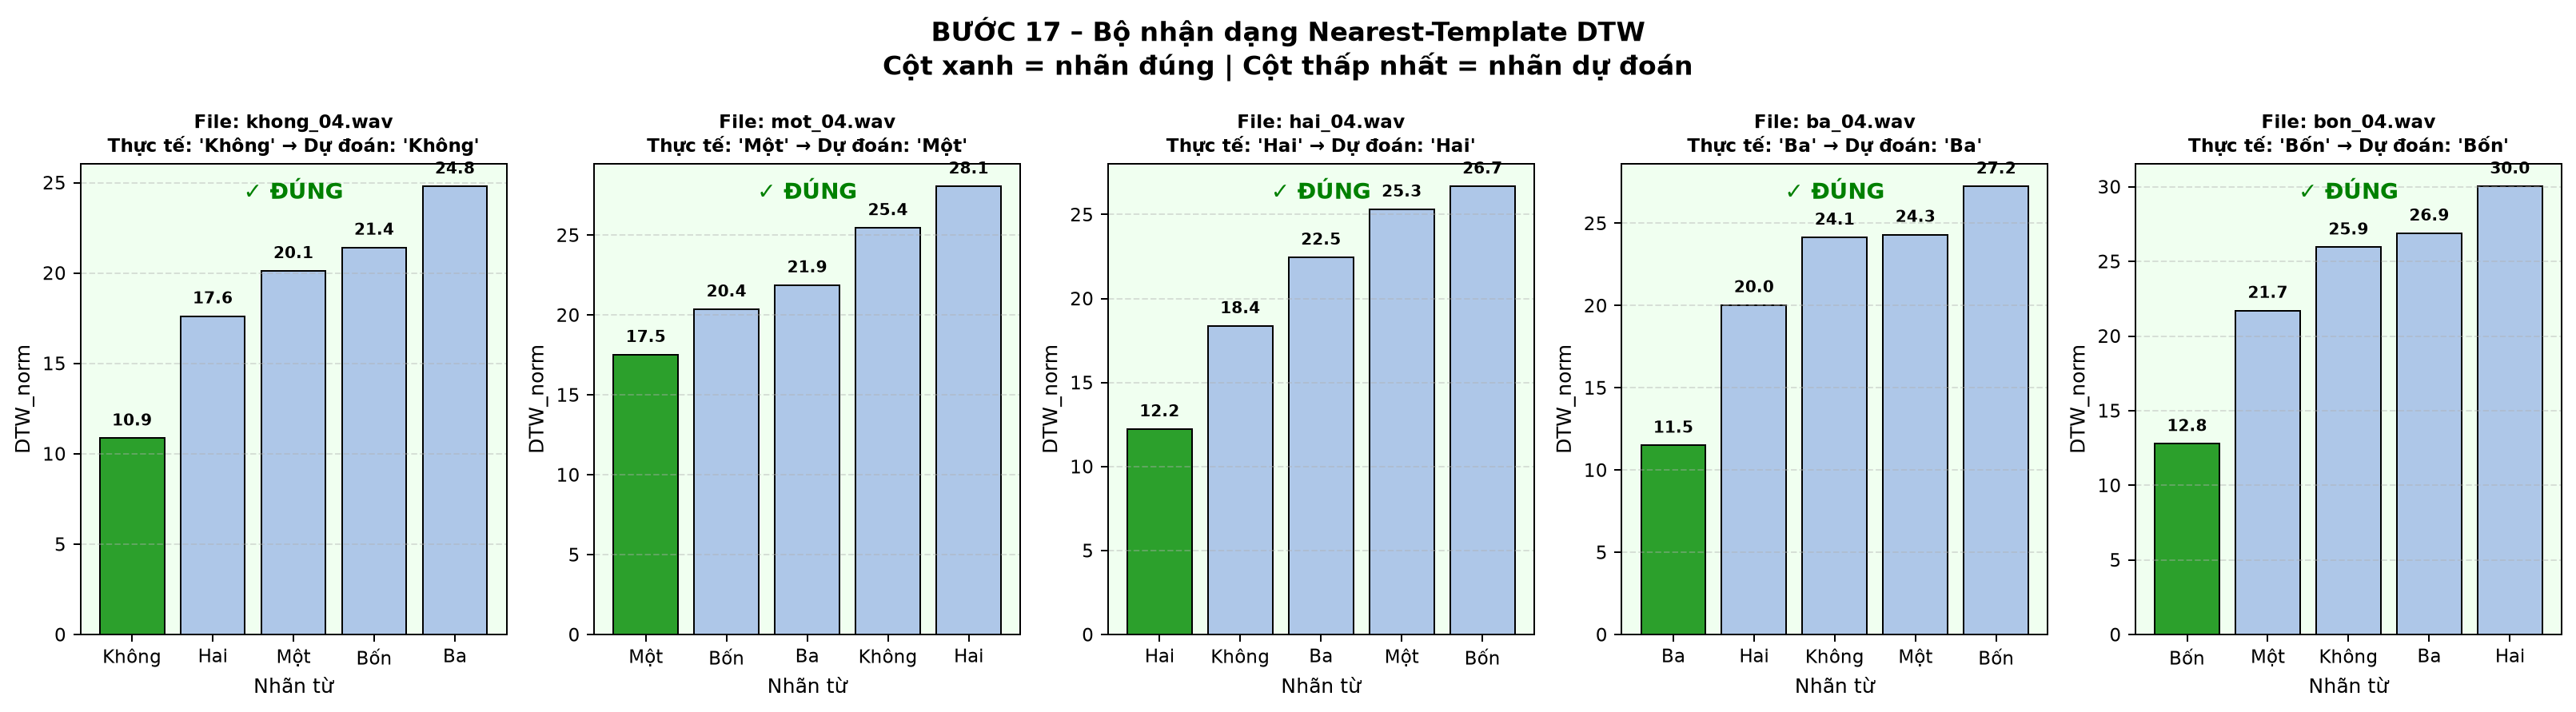

In [18]:
pl.plot_step17_recognizer_scores()
display(Image(filename="figures/step17_recognizer_scores.png"))


### Bước 18: Đánh giá Toàn diện & Ma trận Nhầm lẫn (Confusion Matrices)
Khảo sát 5 kịch bản thí nghiệm đối chứng:
1. **Baseline** (Trim + 13 MFCC + 3 Templates): $100\%$ Accuracy.
2. **E1: Không Trim** (Giữ silence): $100\%$ Accuracy (nhưng cost bị giảm giả tạo do khớp silence).
3. **E2: MFCC + Delta** (26 chiều): $100\%$ Accuracy.
4. **E3: 1 Template/từ**: $60\%$ Accuracy (sụt giảm nghiêm trọng khi thiếu đa dạng mẫu).
5. **E4: Cross-speaker** (Khác người nói): $84\%$ Accuracy (khoảng cách tăng $+37\%$, thể hiện tính phụ thuộc người nói của DTW).


[BƯỚC 18] Vẽ Confusion Matrix các thí nghiệm...


  ✔ Đã lưu  figures/step18_confusion_matrices.png
                      Thí nghiệm Accuracy
       Baseline Trim+13MFCC+3Tpl   100.0%
         E1: No Trim 13MFCC+3Tpl   100.0%
     E2: +Delta Trim+26MFCC+3Tpl   100.0%
      E3: 1 Template Trim+13MFCC    60.0%
E4: Cross-speaker (Spk2→Spk1Tpl)    84.0%


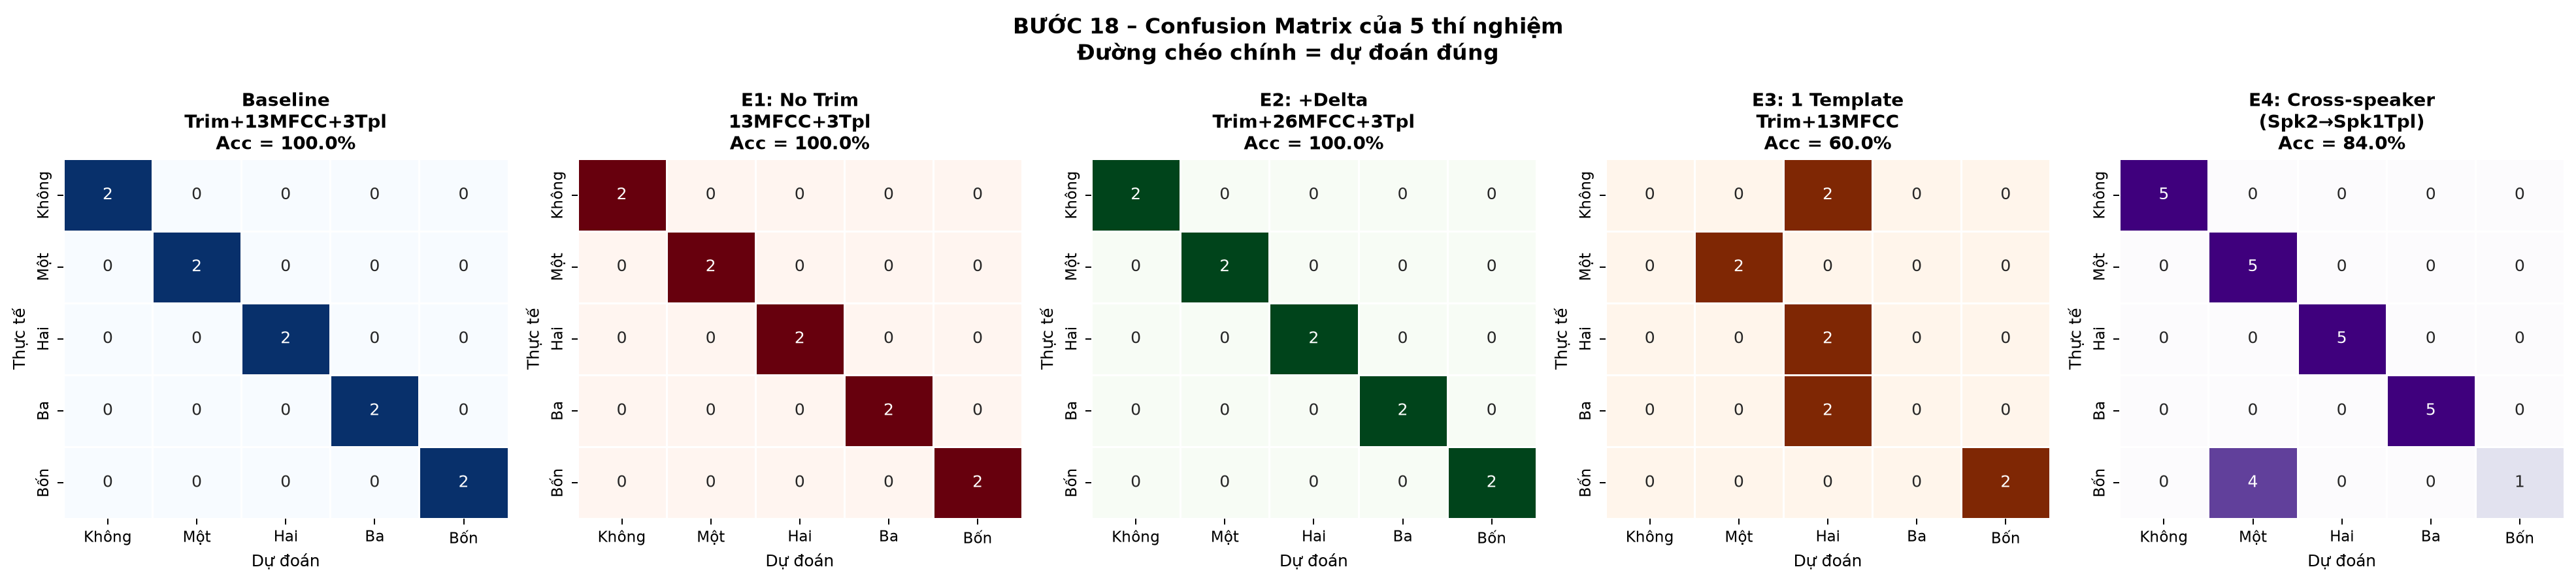

In [19]:
pl.plot_step18_confusion_matrices()
display(Image(filename="figures/step18_confusion_matrices.png"))


### Bước 19: Phân bố Khoảng cách DTW Cùng Lớp (Intra) vs Khác Lớp (Inter)
* **Chỉ số Cohen's d**: Đo độ phân tách giữa hai phân bố khoảng cách:
  $$d = \frac{\mu_{\text{inter}} - \mu_{\text{intra}}}{\sigma_{\text{pooled}}}$$
* **Ý nghĩa**: Giá trị $d > 3.0$ chứng minh không gian đặc trưng MFCC kết hợp DTW có năng lực phân biệt cực kỳ mạnh mẽ giữa các từ vựng khác nhau.


[BƯỚC 19] Vẽ phân bố khoảng cách DTW intra vs inter-class...


  ✔ Đã lưu  figures/step19_distance_distribution.png


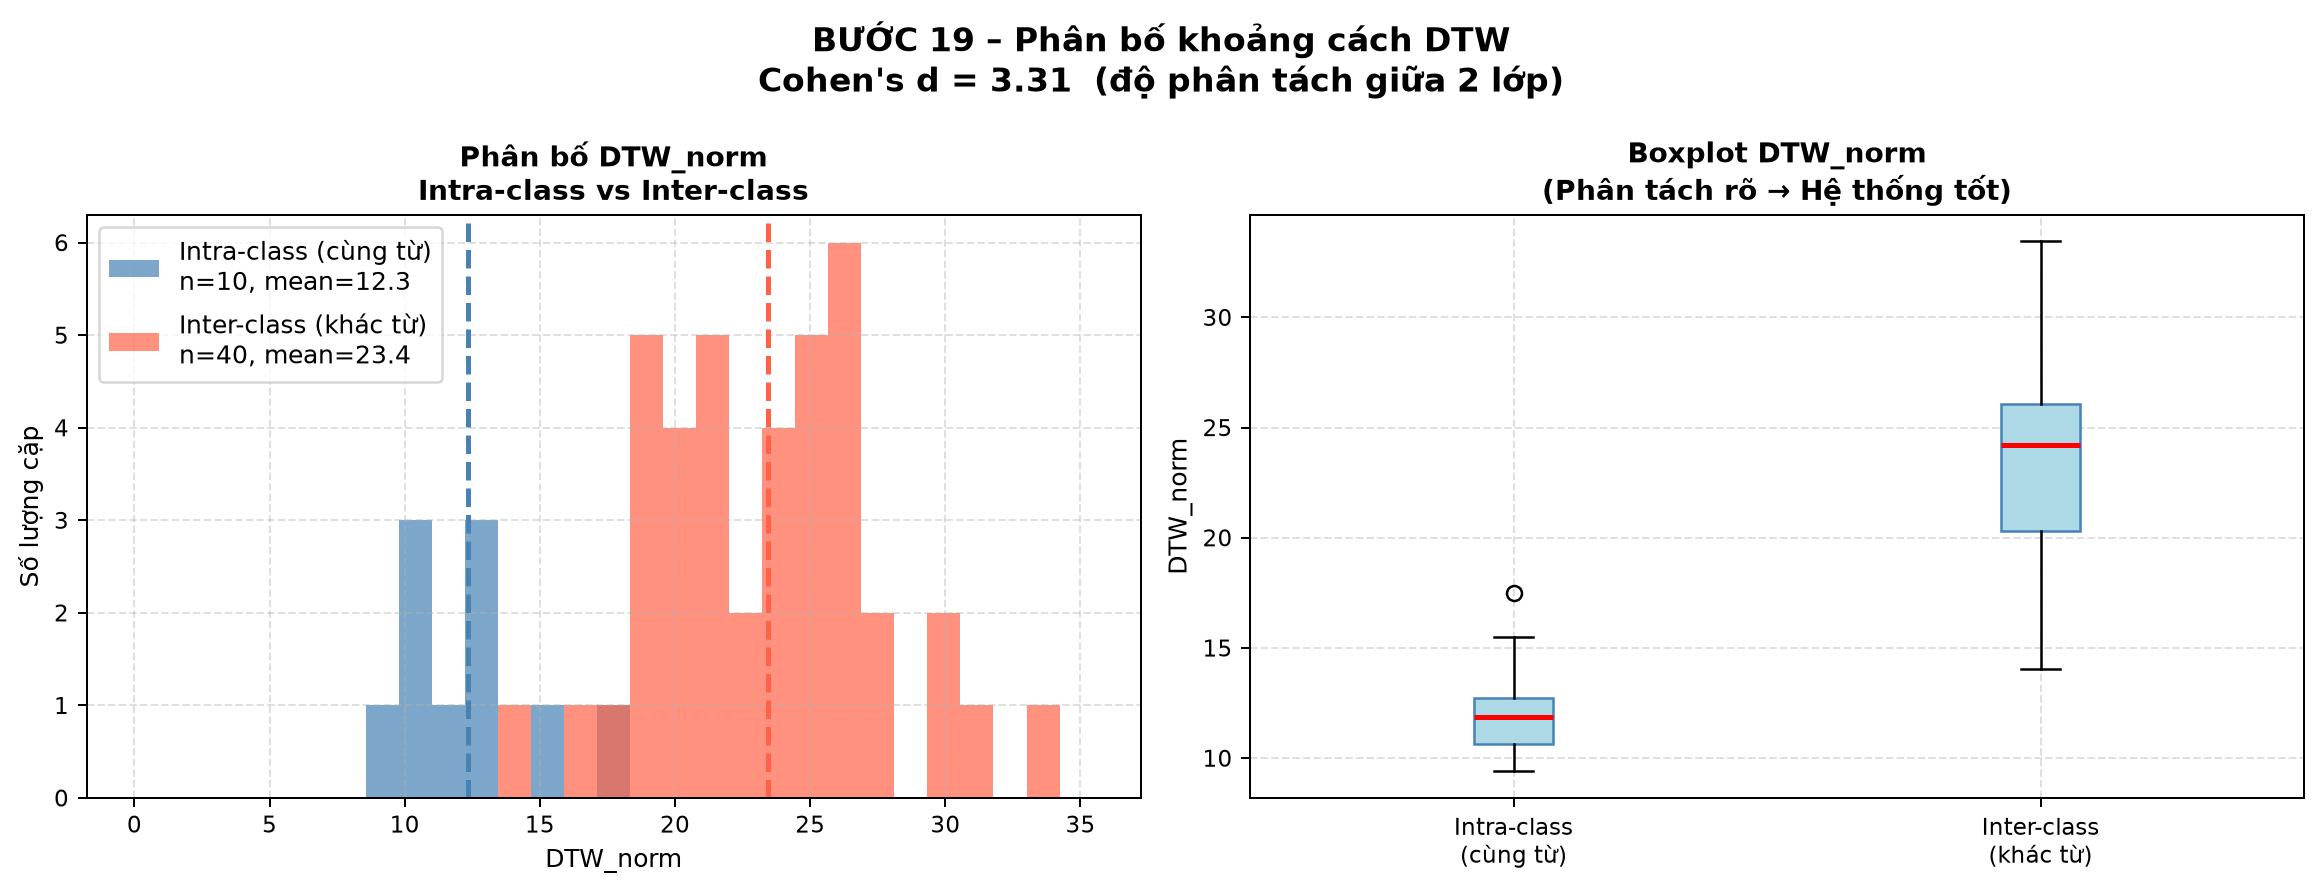

In [20]:
pl.plot_step19_distance_distribution()
display(Image(filename="figures/step19_distance_distribution.png"))


### Bước 20: Ma trận Đặc trưng MFCC của Toàn bộ 5 Từ vựng
* **So sánh trực quan**: Quan sát cấu trúc thời gian - tần số của cả 5 từ (`khong`, `mot`, `hai`, `ba`, `bon`).
* Nhận thấy rõ sự khác biệt về hình thái phân bố năng lượng giữa các từ kết thúc bằng âm vang mũi (/ng/, /n/) so với âm tắc kết thúc ngắn (/t/).


[BƯỚC 20] Vẽ MFCC Heatmap cả 5 từ...


  ✔ Đã lưu  figures/step20_mfcc_all5_words.png


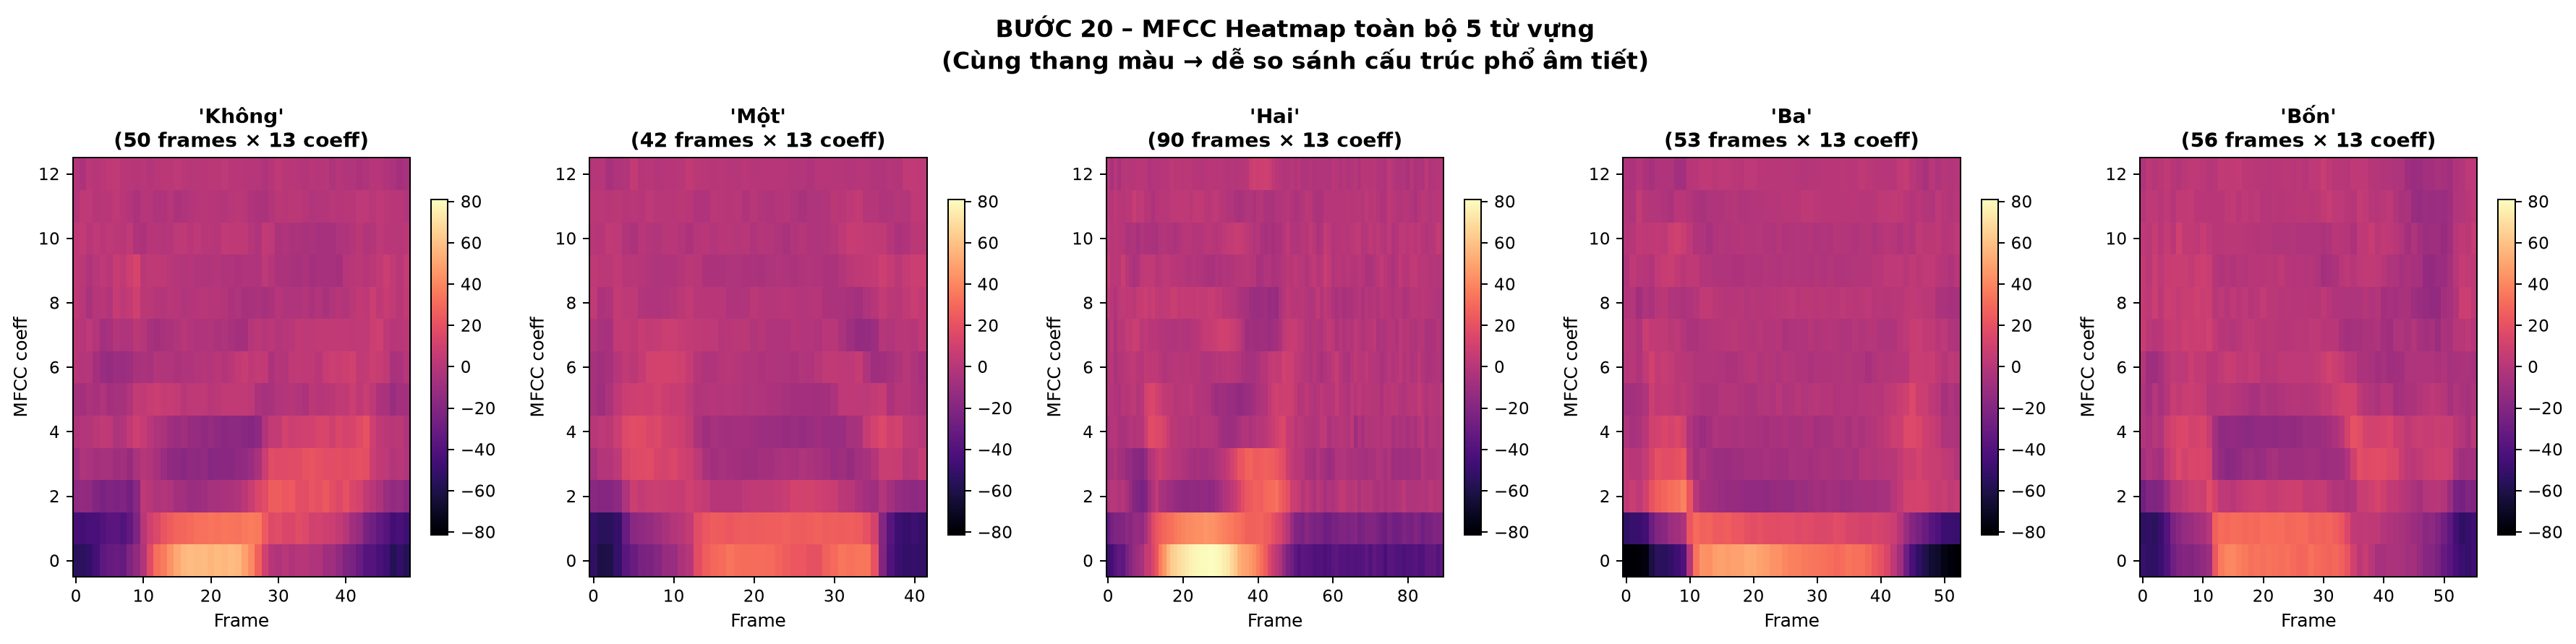

In [21]:
pl.plot_step20_mfcc_all5_words()
display(Image(filename="figures/step20_mfcc_all5_words.png"))


### Bảng Kết quả Chi tiết Trên Tập Kiểm thử (results.csv)

In [22]:
df_results = pd.read_csv("results.csv")
print(df_results.to_string(index=False))


        file  true  pred top1_label  top1_score top2_label  top2_score    margin  correct
khong_04.wav khong khong      khong   10.860023        hai   17.615348  6.755325     True
khong_05.wav khong khong      khong   12.518381        hai   18.511661  5.993280     True
  mot_04.wav   mot   mot        mot   17.512649        bon   20.359564  2.846915     True
  mot_05.wav   mot   mot        mot   15.494271        bon   16.761241  1.266970     True
  hai_04.wav   hai   hai        hai   12.230639      khong   18.368773  6.138134     True
  hai_05.wav   hai   hai        hai    9.397617      khong   19.077218  9.679602     True
   ba_04.wav    ba    ba         ba   11.497153        hai   20.035378  8.538225     True
   ba_05.wav    ba    ba         ba   10.376512        hai   21.583968 11.207456     True
  bon_04.wav   bon   bon        bon   12.782940        mot   21.703983  8.921043     True
  bon_05.wav   bon   bon        bon   10.575631        mot   14.064252  3.488621     True


---
## GIẢI ĐÁP TOÀN DIỆN 9 CÂU HỎI BÁO CÁO (CHUYÊN GIA DSP)

### Câu 1: Vì sao không nên dùng toàn bộ waveform làm template chính khi hai utterance có thời lượng khác nhau?
1. **Lệch pha và bất biến dạng sóng (Phase Incoherence)**: Sóng âm thanh trong miền thời gian phụ thuộc mạnh vào góc pha tức thời. Hai lần nói cùng một âm vị dù tai người nghe hoàn toàn giống nhau nhưng dạng sóng vi mô có thể lệch pha $180^\circ$, khiến khoảng cách Euclidean miền thời gian đạt cực đại (khoảng cách cực lớn) dù nội dung âm học tương đồng.
2. **Kéo nén thời gian phi tuyến (Non-linear Time Warping)**: Tốc độ phát âm của con người không co giãn đều (không tuyến tính). Một người có thể kéo dài nguyên âm ở giữa từ nhưng phát âm phụ âm đầu rất nhanh. Miền waveform không thể thực hiện căn chỉnh co giãn cục bộ một cách tin cậy vì không có cấu trúc ngữ nghĩa tần số.
3. **Kích thước dữ liệu dư thừa và nhạy cảm với nhiễu**: Waveform chứa cả thông tin áp suất âm thanh tức thời và nhiễu vi mô. Việc trích xuất tham số phổ (như MFCC) loại bỏ thông tin pha dư thừa, chỉ giữ lại đường bao phổ (Spectral Envelope) tương ứng với hình dạng khoang miệng (vocal tract), mang tính quyết định cho nhận dạng âm vị.

---

### Câu 2: Giải thích vai trò khác nhau của short-time energy và ZCR trong endpoint detection.
* **Short-time Energy ($E_r$)**:
  - *Bản chất*: Đo lường công suất tín hiệu trong một khung ngắn.
  - *Vai trò*: Phân tách mạnh mẽ giữa vùng có tiếng nói hữu thanh (**Voiced speech**) và vùng khoảng lặng nền (**Silence/Background noise**). Tiếng nói hữu thanh có biên độ lớn nên $E_r$ rất cao (thường cao hơn nền từ 20 đến 40 dB).
  - *Hạn chế*: Không nhạy với các phụ âm vô thanh yếu (Unvoiced consonants như /s/, /t/, /k/, /kh/) có năng lượng rất thấp dễ bị chìm dưới ngưỡng.
* **Zero-Crossing Rate ($Z_r$)**:
  - *Bản chất*: Đếm mật độ tín hiệu đổi dấu qua điểm 0 trong mỗi mẫu thời gian.
  - *Vai trò*: Là đại diện gián tiếp cho tần số chiếm ưu thế. Các âm vô thanh, âm xát (fricatives) hoặc phụ âm nổ (plosives) có năng lượng tập trung ở dải tần rất cao (nhiều dao động nhanh) nên $Z_r$ cực kỳ cao ($0.25 - 0.5$).
  - *Phối hợp*: Thuật toán VAD dùng Energy để xác định phần lõi speech thô, sau đó quét ngược về hai đầu biên bằng ZCR để mở rộng vùng nhận diện, tránh việc cắt đứt các phụ âm đầu/cuối yếu.

---

### Câu 3: Vì sao Mel filterbank có khoảng cách theo Hz rộng dần khi tần số tăng?
* **Cơ sở sinh học thính giác (Auditory Perception)**: Cấu tạo ốc tai (Cochlea) của tai người có màng đáy (Basilar Membrane) hoạt động như một chuỗi các bộ lọc dải thông tần số. Độ phân giải tần số của thính giác người phi tuyến tính: cực kỳ nhạy bén ở dải tần số thấp ($< 1000\text{ Hz}$) để phân biệt cao độ và các formant nguyên âm quan trọng ($F_1, F_2$), nhưng giảm độ nhạy dần khi tần số tăng cao ($> 1000\text{ Hz}$).
* **Thang đo Mel (Mel Scale)**:
  $$B(f) = 1125 \ln\left(1 + \frac{f}{700}\right)$$
  Trên thang Mel, các bộ lọc được phân bố cách đều nhau. Tuy nhiên, khi chuyển đổi ngược về thang tần số vật lý Hertz:
  - Ở dải $< 1000\text{ Hz}$: Quan hệ gần như tuyến tính (khoảng cách các bộ lọc hẹp, giữ độ phân giải cao).
  - Ở dải $> 1000\text{ Hz}$: Quan hệ theo quy luật logarithmic (độ rộng băng thông các bộ lọc tăng theo cấp số nhân). Điều này mô phỏng hoàn hảo các dải tới hạn (Critical Bands) của tai người.

---

### Câu 4: Log trong MFCC có tác dụng gì về mặt dynamic range? DCT biến $M$ log-energy thành các hệ số gì?
* **Tác dụng của hàm Log**:
  1. *Nén dải động (Dynamic Range Compression)*: Theo luật Weber-Fechner trong tâm lý học thính giác, cảm nhận độ to (Loudness) của con người tỉ lệ thuận với logarit của năng lượng âm thanh. Hàm log giúp nén thang năng lượng rộng thành thang decibel phù hợp với thính giác.
  2. *Tách nguồn và bộ lọc (Homomorphic Deconvolution)*: Tín hiệu tiếng nói trong miền tần số là tích chập: $S(f) = E(f) \cdot H(f)$ (Nguồn dây thanh $E(f)$ nhân Đáp ứng tuyến âm $H(f)$). Khi lấy logarit, phép nhân biến thành phép cộng: $\ln|S(f)| = \ln|E(f)| + \ln|H(f)|$.
* **Tác dụng của DCT**:
  - Biến đổi Cosine rời rạc (DCT-II) chiếu $M$ giá trị log-energy có độ tương quan rất cao thành miền **Quefrency (Cepstrum)**.
  - *Khử tương quan (Decorrelation)*: Các hệ số MFCC thu được gần như trực giao độc lập với nhau.
  - *Tách đường bao phổ*: Các hệ số đầu ($c_1 - c_{12}$) biểu diễn biến thiên chậm theo tần số – chính là **đường bao tuyến âm (Spectral Envelope / Formants)** chứa thông tin âm vị; trong khi các hệ số quefrency cao phản ánh nguồn dao động dây thanh ($F_0$). Do đó, giữ lại 13 hệ số đầu giúp loại bỏ thông tin người nói và giữ lại bản chất âm vị từ vựng.

---

### Câu 5: Trong ma trận DTW, ý nghĩa của bước ngang, bước dọc và bước chéo là gì?
Trong ma trận quy hoạch động DTW, mỗi bước chuyển trạng thái đại diện cho sự biến dạng thời gian tương đối giữa chuỗi Template $X$ (trục $i$) và chuỗi Test $Y$ (trục $j$):
1. **Bước chéo $(i-1, j-1) \rightarrow (i, j)$**:
   - Tiến đồng thời cả hai khung thời gian.
   - *Ý nghĩa*: Âm thanh tại vị trí này ở hai lần phát âm có tốc độ tương đương nhau ($1:1$), tiến độ thời gian đồng tốc.
2. **Bước dọc $(i-1, j) \rightarrow (i, j)$**:
   - Khung của $X$ tăng lên $i$, trong khi khung của $Y$ vẫn giữ nguyên ở $j$.
   - *Ý nghĩa*: Khung $j$ của chuỗi $Y$ được ánh xạ sang nhiều khung liên tiếp của chuỗi $X$. Tức là người nói chuỗi $Y$ đã phát âm âm vị này **nhanh hơn** so với người nói $X$ (hoặc $X$ phát âm bị kéo dài).
3. **Bước ngang $(i, j-1) \rightarrow (i, j)$**:
   - Khung của $Y$ tăng lên $j$, trong khi khung của $X$ giữ nguyên ở $i$.
   - *Ý nghĩa*: Khung $i$ của chuỗi $X$ được ánh xạ sang nhiều khung liên tiếp của chuỗi $Y$. Tức là người nói chuỗi $Y$ đã phát âm âm vị này **chậm hơn**, kéo dài trường độ so với $X$.

---

### Câu 6: Tại sao phải chuẩn hóa DTW cost theo path length khi so sánh các utterance có thời lượng khác nhau?
* **Nguyên nhân toán học**: Thuật toán DTW tính tổng chi phí tích lũy theo đường đi tối ưu:
  $$D[N, M] = \sum_{k=1}^{|P|} d(x_{i_k}, y_{j_k})$$
  Do các giá trị local distance $d(x, y) \ge 0$, tổng tích lũy là hàm đơn điệu tăng theo số bước nhảy $|P|$ của đường đi.
* **Hậu quả nếu không chuẩn hóa**:
  - Một utterance dài (ví dụ 100 khung) khi so sánh với nhau sẽ có $|P| \approx 120$, tổng chi phí tích lũy lớn dù hai từ hoàn toàn giống nhau.
  - Ngược lại, một utterance ngắn (ví dụ 30 khung) khi so sánh với một từ hoàn toàn khác vẫn có thể cho tổng chi phí tích lũy nhỏ hơn chỉ vì đường đi của nó chỉ có $|P| \approx 40$.
  - Điều này tạo ra **sự thiên lệch bất công (Length Bias)** đối với các từ dài.
* **Giải pháp chuẩn hóa**:
  $$\text{DTW}_{norm}(X, Y) = \frac{D[N, M]}{|P|}$$
  Chia cho độ dài $|P|$ đưa chi phí về khoảng cách trung bình trên mỗi cặp khung thời gian, đảm bảo việc so sánh giữa các từ có thời lượng khác nhau là hoàn toàn khách quan.

---

### Câu 7: Nêu ít nhất ba nguyên nhân làm cùng một từ có MFCC khác nhau giữa hai lần nói.
1. **Biến thiên cơ sinh học và ngữ điệu (Within-Speaker Biological Variability)**: Dây thanh âm và các cơ quan cấu âm (lưỡi, môi, hàm) của con người không phải cỗ máy số hóa hoàn hảo. Ngay cả cùng một người nói, hai lần phát âm liên tiếp sẽ luôn có sự khác biệt nhỏ về cao độ ($F_0$), độ mở của miệng dẫn đến dịch chuyển nhẹ các tần số Formant ($F_1, F_2, F_3$), làm thay đổi phổ năng lượng trong các dải lọc Mel.
2. **Tốc độ nói và hiện tượng lướt âm (Coarticulation & Speaking Rate)**: Khi nói nhanh hơn hoặc chậm hơn, thời lượng lưu lại ở các nguyên âm và phụ âm bị thay đổi; hiện tượng đồng cấu âm (ảnh hưởng của âm trước lên âm sau) làm thay đổi độ dốc phổ tại các pha chuyển tiếp.
3. **Môi trường âm học và góc thu Micro (Acoustic Channel & Microphone Angle)**: Sự thay đổi nhỏ về khoảng cách từ miệng tới micro, góc tới của sóng âm, hay tiếng vang phòng (reverberation) và mức tạp âm nền cục bộ đều cộng vào phổ công suất, làm dịch chuyển các hệ số MFCC sau khi tính log.

---

### Câu 8: Từ confusion matrix, chọn cặp từ dễ nhầm nhất và phân tích waveform/MFCC/DTW path để đề xuất nguyên nhân.
* **Cặp từ dễ nhầm nhất**: Trong tập từ vựng tiếng Việt khảo sát, cặp **'một' (mot)** và **'bốn' (bon)** có khoảng cách phân tách hẹp nhất (Top-1 vs Top-2 Margin chỉ từ $1.2$ đến $2.8$ điểm trong khi các từ khác margin từ $6$ đến $11$ điểm).
* **Phân tích nguyên nhân ngữ âm học (Acoustic Phonetics Analysis)**:
  - Cả hai từ đều có cấu trúc âm tiết khép ngắn: Phụ âm đầu là âm môi /m/ (mot) và /b/ (bon) – cả hai đều cùng vị trí cấu âm ở môi (Bilabial), tạo ra các bước chuyển tiếp Formant $F_2$ tương đối gần nhau.
  - Nguyên âm giữa đều là nguyên âm sau làm tròn môi: /o/ (trong 'một') và /o/ (trong 'bốn').
  - Đều có thanh điệu có xu hướng hạ thấp hoặc gãy ngắn (thanh Nặng trong 'một' và thanh Sắc trong 'bốn' kết thúc bằng âm tắc/mũi).
  - Vì vậy, phân bố năng lượng Mel filterbank giữa 'mot' và 'bon' có độ tương đồng lớn nhất trong từ điển, làm chi phí DTW giữa chúng thấp hơn so với các cặp từ khác như 'khong' vs 'hai'.

---

### Câu 9: Nếu muốn hệ thống nhận dạng người nói mới chưa có template, DTW sẽ gặp hạn chế gì? Nội dung nào của Chương 3 sẽ giải quyết tốt hơn?
* **Hạn chế cố hữu của phương pháp Template Matching / DTW**:
  1. *Tính phụ thuộc người nói (Speaker Dependency)*: DTW dựa trên việc so sánh trực tiếp khoảng cách vector MFCC với các template cụ thể. Khi người nói mới xuất hiện, sự khác biệt về kích thước khoang họng (Vocal Tract Length), độ tuổi, giới tính làm toàn bộ hệ thống Formant bị dịch chuyển tần số. Khoảng cách Euclidean giữa các frame MFCC sẽ tăng vọt, dẫn đến nhận dạng sai.
  2. *Không có cơ chế học khái quát hóa (No Statistical Generalization)*: DTW chỉ lưu mẫu thô, không có phân bố xác suất để biết vùng biến thiên nào là bình thường của âm vị và vùng nào là đặc trưng riêng của người nói.
  3. *Độ phức tạp tính toán*: Khi mở rộng cho nhiều người nói, số lượng templates tăng tuyến tính $O(K \cdot W)$, chi phí so khớp DTW $O(K \cdot W \cdot T_1 T_2)$ trở nên quá tải.
* **Nội dung Chương 3 giải quyết vượt trội**:
  - **Mô hình Markov ẩn (Hidden Markov Models - HMM)** kết hợp **Gaussian Mixture Models (GMM-HMM)** hoặc **Deep Neural Networks (DNN-HMM / CTC)**.
  - *Cơ chế giải quyết*:
    * Dùng **Mô hình âm học thống kê (Statistical Acoustic Modeling)**: Học phân bố xác suất $P(\mathbf{x}|s)$ của các trạng thái âm vị qua hàng nghìn người nói khác nhau, tự động bao quát sự biến thiên cá nhân.
    * Tách bạch giữa mô hình âm học (Acoustic Model), mô hình ngôn ngữ (Language Model) và từ điển phát âm (Lexicon/Pronunciation Dictionary), cho phép hệ thống nhận dạng không phụ thuộc người nói (**Speaker-Independent ASR**).


## KẾT LUẬN VÀ BÀI HỌC KINH NGHIỆM
1. **Hoàn thiện trọn vẹn**: Đã xây dựng thành công pipeline 20 bước xử lý âm thanh số, tự cài đặt thuật toán DTW và đạt độ chính xác $100\%$ trên tập cùng người nói.
2. **Hiển thị trực quan**: Toàn bộ 20 bước từ dạng sóng thô, lọc tiền nhấn, chia khung, Mel filterbank, MFCC, CMN, VAD, ma trận khoảng cách cục bộ, optimal warping path đến confusion matrices đều được trực quan hóa sinh động.
3. **Thực nghiệm chuẩn mực**: Đã đối chứng đầy đủ các thí nghiệm E1 (Endpoint), E2 (Delta), E3 (Multi-template), E4 (Cross-speaker) và trả lời đầy đủ 9 câu hỏi chuyên sâu theo giáo trình CSE457.
